## Histograms and heat maps 

In [1]:
from pathlib import Path
import re
 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
 
 
PROCESSED_DIR = Path("data/processed")
 
TASK_CONFIGS = {
    "healthy_vs_infected": {
        "class_labels": ["Healthy", "Infected"],
        "palette": ["#5B9BD5", "#FA8123"], 
    },
    "symptomatic_non_covid_vs_covid": {
        "class_labels": ["Symptomatic-non-COVID-19", "COVID-19"],
        "palette": ["#70AD47", "#FF69B4"], 
    },
    "severe_vs_nonsevere": {
        "class_labels": ["Non-severe-COVID-19", "Severe-COVID-19"],
        "palette": ["#9966CB", "#FF4444"], 
    },
}
 
TOP_N_FEATURES = 10 # number of top peptides to visualise
N_BINS = 20 # histogram bins 


# Helpers
 
def load_task(task_name: str) -> dict:
    # Load all data files for one task and return as a dict
    task_dir   = PROCESSED_DIR / task_name
    X_train    = pd.read_csv(task_dir / "X_train_scaled.csv",  index_col=0)
    X_test     = pd.read_csv(task_dir / "X_test_scaled.csv",   index_col=0)
    meta_train = pd.read_csv(task_dir / "metadata_train.csv",  index_col=0)
    meta_test  = pd.read_csv(task_dir / "metadata_test.csv",   index_col=0)
 
    X_all    = pd.concat([X_train, X_test],     axis=0)
    meta_all = pd.concat([meta_train, meta_test], axis=0)
    X_all    = X_all.loc[meta_all.index]
 
    coef_df = pd.read_csv(
        task_dir / "top10_logreg_features.csv",
        comment="#"
    )
    coef_df.columns = coef_df.columns.str.strip()
    coef_df = coef_df[coef_df["peptide"].isin(X_all.columns)].copy()
 
    X_train_missing = pd.read_csv(task_dir / "X_train_missing.csv", index_col=0)
    X_test_missing  = pd.read_csv(task_dir / "X_test_missing.csv",  index_col=0)
    missing_all = pd.concat([X_train_missing, X_test_missing], axis=0)
    missing_all = missing_all.loc[meta_all.index]   # align row order
 
    return {"task_dir": task_dir, "X_all": X_all,
            "missing_all": missing_all,
            "meta_all": meta_all, "coef_df": coef_df}
 
 
def shorten_peptide(name: str, max_len: int = 55) -> str:
    return name if len(name) <= max_len else name[:max_len - 1] + "…"
 
 
def slugify(name: str, max_len: int = 40) -> str:
    # Safe filename fragment from a peptide string
    slug = re.sub(r"[^\w]", "_", name)
    return slug[:max_len]
 

In [2]:
# Plot histogram for a peptide 
 
def plot_single_histogram(
    peptide: str,
    coef: float,
    rank: int,
    X_all: pd.DataFrame,
    meta_all: pd.DataFrame,
    class_labels: list,
    palette: list,
    task_title: str,
    save_path: Path | None = None,
) -> None:
    """
    Figure showing overlapping per-class intensity histograms for a
    single peptide, with per-class mean lines and a stats annotation box
    """
    label_col = "label_name"
 
    # Collect per-class values 
    class_values = {}
    for cls_label in class_labels:
        mask = meta_all[label_col] == cls_label
        class_values[cls_label] = X_all.loc[mask, peptide].dropna().values
 
    combined = np.concatenate(list(class_values.values()))
    bin_edges = np.linspace(combined.min(), combined.max(), N_BINS + 1)
 
    # Figure 
    fig, ax = plt.subplots(figsize=(7, 4.5))
 
    for cls_label, color in zip(class_labels, palette):
        ax.hist(
            class_values[cls_label],
            bins=bin_edges,
            alpha=0.6,
            color=color,
            edgecolor="white",
            linewidth=0.4,
        )
 
    # Per-class mean lines
    class_means = {}
    class_stds = {}
    for cls_label, color in zip(class_labels, palette):
        vals = class_values[cls_label]
        mu = vals.mean()
        sd = vals.std()
        class_means[cls_label] = mu
        class_stds[cls_label] = sd
        ax.axvline(
            mu,
            color=color,
            linestyle="--",
            linewidth=1.8,
            zorder=5,
            label=f"{cls_label}  (mean={mu:.3f})",
        )
 
    # Stats annotation box 
    mean_vals = list(class_means.values())
    mean_diff = mean_vals[1] - mean_vals[0]   # class[1] - class[0]
    stats_lines = []
    for cls_label, color in zip(class_labels, palette):
        mu = class_means[cls_label]
        sd = class_stds[cls_label]
        n = len(class_values[cls_label])
        stats_lines.append(
            f"{cls_label}\n  n={n},  mean={mu:.3f},  sd={sd:.3f}"
        )
    stats_lines.append(f"\nMean difference: {mean_diff:+.3f}")
    stats_text = "\n".join(stats_lines)
 
    ax.text(
        0.98, 0.72, stats_text,
        transform=ax.transAxes,
        fontsize=7.5,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                edgecolor="#cccccc", alpha=0.9),
        family="monospace",
    )
 
    # Legend (colors + mean-line marker) 
    hist_handles = [
        mpatches.Patch(color=c, alpha=0.65, label=lbl)
        for c, lbl in zip(palette, class_labels)
    ]
    mean_handle = plt.Line2D(
        [], [], color="grey", linestyle="--", linewidth=1.6, label="class mean"
    )
    ax.legend(
        handles=hist_handles + [mean_handle],
        title="Condition",
        fontsize=8,
        title_fontsize=8,
        frameon=True,
        loc="upper right",
    )
 
    # Labels / title 
    ax.set_title(
        f"Rank {rank}: {shorten_peptide(peptide, 52)}\n"
        f"coef = {coef:+.3f}  |  {task_title}",
        fontsize=9, pad=6,
    )
 
    ax.set_xlabel(
        "Scaled intensity  (log1p + StandardScaler)\n"
        "0 = population mean; negative = below mean",
        fontsize=8,
    )
 
    ax.set_ylabel("Number of patients", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
 
    plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor="white", edgecolor="white")
        print(f"    Saved: {save_path.name}")
    plt.show()
    plt.close(fig)
 
 
def plot_intensity_histograms(
    task_name: str,
    X_all: pd.DataFrame,
    meta_all: pd.DataFrame,
    coef_df: pd.DataFrame,
    class_labels: list,
    palette: list,
    top_n: int = TOP_N_FEATURES,
    task_dir: Path | None = None,
) -> None:
    # Iterate over the top-N peptides and save one histogram figure each
    top_peptides = (
        coef_df[coef_df["abs_coefficient"] > 0]
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
 
    task_title = task_name.replace("_", " ").title()
 
    for rank, row in top_peptides.iterrows():
        peptide = row["peptide"]
        coef = row["coefficient"]
        rank_1 = rank + 1  # 1-based
 
        save_path = None
        if task_dir:
            hist_dir = task_dir / "histograms"
            hist_dir.mkdir(exist_ok=True)
            fname = f"histogram_{rank_1:02d}_{slugify(peptide)}.png"
            save_path = hist_dir / fname
 
        plot_single_histogram(
            peptide=peptide,
            coef=coef,
            rank=rank_1,
            X_all=X_all,
            meta_all=meta_all,
            class_labels=class_labels,
            palette=palette,
            task_title=task_title,
            save_path=save_path,
        )
 

In [3]:
# Feature intensity heatmap 
 
def plot_intensity_heatmap(
    task_name: str,
    X_all: pd.DataFrame,
    missing_all: pd.DataFrame,
    meta_all: pd.DataFrame,
    coef_df: pd.DataFrame,
    class_labels: list,
    palette: list,
    top_n: int = TOP_N_FEATURES,
    show_missing: bool = True,  # Show missing values as white or leave imputed 0
    save_path: Path | None = None,
) -> None:
    """
    Heatmap of peptide intensities across all patients.
    
    - Rows = top-N peptides, sorted by coefficient (most positive at top)
    - Columns = patients, sorted by class then sample ID
    - Colored band at the top marks each patient's class (condition)
    - Color scale (viridis, right-hand side) = scaled intensity. 
        Yellow / bright = high intensity; dark purple = low / absent.

    Look for rows/peptides that show a clear color split between the classes
    """
    top_peptides = (
        coef_df[coef_df["abs_coefficient"] > 0]
        .sort_values("coefficient", ascending=False)
        .head(top_n)
    )
    selected_peptides = top_peptides["peptide"].tolist()
 
    label_col = "label_name"
    meta_sorted = (
        meta_all
        .assign(_cls_order=meta_all[label_col].map(
            {lbl: i for i, lbl in enumerate(class_labels)}
        ))
        .sort_values(["_cls_order", "sample_id"])
    )
    patient_order = meta_sorted.index
 
    heat_data = X_all.loc[patient_order, selected_peptides].T
    heat_data.index = [shorten_peptide(p, 55) for p in heat_data.index]
 
    n_patients = len(patient_order)
    fig_w = max(14, n_patients * 0.28 + 5)
    fig_h = max(5,  top_n * 0.6 + 3)
 
    # Build figure 
 
    fig = plt.figure(figsize=(fig_w, fig_h))
 
    # Fractions
    left_margin = 0.26 # room for long peptide labels on the left
    right_margin = 0.08 # room for colorbar on the right
    cbar_width = 0.018
    cbar_gap = 0.015
    top_band_h = 0.06 # class annotation band height (fraction of fig height)
    bottom_margin = 0.22 # extra room for rotated sample ID labels
    top_margin = 0.14
 
    heatmap_left = left_margin
    heatmap_bottom = bottom_margin
    heatmap_width = 1 - left_margin - right_margin - cbar_width - cbar_gap
    heatmap_height = 1 - bottom_margin - top_margin - top_band_h - 0.02
 
    ax_heat = fig.add_axes([heatmap_left,
                              heatmap_bottom,
                              heatmap_width,
                              heatmap_height])
 
    ax_band = fig.add_axes([heatmap_left,
                              heatmap_bottom + heatmap_height + 0.01,
                              heatmap_width,
                              top_band_h])
 
    ax_cbar = fig.add_axes([heatmap_left + heatmap_width + cbar_gap,
                              heatmap_bottom,
                              cbar_width,
                              heatmap_height])

    # Draw heatmap 
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="white")   # missing cells - white

    # np.ma.masked_array: masked cells are not rendered by imshow (shown as
    # the colormap's "bad" colour, which we set to white below)
    heat_values  = heat_data.values.astype(float)

    # Build missing mask from pre-imputation matrix
    if show_missing:
        heat_mask = missing_all.loc[patient_order, selected_peptides].T.isna()
        heat_mask.index = heat_data.index # align shortened peptide names
        heat_missing = heat_mask.values
        masked_data = np.ma.masked_where(heat_missing, heat_values)
        cmap = plt.get_cmap("viridis").copy()
        cmap.set_bad(color="white")
    else:
        masked_data = heat_values   # plain array, no masking
        cmap = plt.get_cmap("viridis").copy()

    im = ax_heat.imshow(
        masked_data,
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
    )
 
    # Y axis – peptide labels on the left
    ax_heat.set_yticks(range(len(heat_data)))
    ax_heat.set_yticklabels(heat_data.index, fontsize=7)
    ax_heat.yaxis.set_label_position("left")
    ax_heat.yaxis.tick_left()
    ax_heat.set_ylabel("Peptide", fontsize=9)
 
    # Color y-tick labels by coefficient sign
    # coef_lookup = dict(zip(
    #     [shorten_peptide(p, 55) for p in top_peptides["peptide"]],
    #     top_peptides["coefficient"],
    # ))
    # for lbl in ax_heat.get_yticklabels():
    #     c = coef_lookup.get(lbl.get_text(), 0)
    #     lbl.set_color("#c0392b" if c > 0 else "#2980b9")
 
    # X axis – one tick per patient, labelled with sample ID
    sample_ids = meta_sorted.loc[patient_order, "sample_id"].tolist()
    ax_heat.set_xticks(range(n_patients))
    ax_heat.set_xticklabels(
        sample_ids,
        rotation=90,
        fontsize=6,
        ha="center",
    )
    ax_heat.set_xlabel(
        f"Sample ID  (n={n_patients}, sorted by class then sample ID)",
        fontsize=9,
    )
 
    # Class annotation band (top) 
    # Map hex → numeric index for imshow
    color_index = np.array(
        [class_labels.index(meta_sorted.loc[idx, label_col]) for idx in patient_order]
    ).reshape(1, -1)
 
    cmap_band = plt.matplotlib.colors.ListedColormap(palette)
    ax_band.imshow(color_index, aspect="auto", cmap=cmap_band,
                   vmin=0, vmax=len(class_labels) - 1, interpolation="nearest")
    ax_band.set_xticks([])
    ax_band.set_yticks([])
    for spine in ax_band.spines.values():
        spine.set_visible(False)
 
    # Legend for the class band
    legend_handles = [
        mpatches.Patch(color=c, label=lbl)
        for c, lbl in zip(palette, class_labels)
    ]
    ax_band.legend(
        handles=legend_handles,
        title="Condition",
        title_fontsize=8,
        fontsize=8,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
    )
 
    # Colorbar on the right
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label(
        "Scaled intensity\n(log1p + StandardScaler)",
        fontsize=8,
        labelpad=6,
    )
    cbar.ax.tick_params(labelsize=7)
 
    # Title 
    task_title = task_name.replace("_", " ").title()
    fig.text(
        0.5,
        0.97,
        f"Peptide Intensity Heatmap – Top {top_n} Features\n{task_title}",
        ha="center", va="top",
        fontsize=12, fontweight="medium",
    )
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor="white", edgecolor="white")
        print(f"  Saved: {save_path.name}")
    plt.show()
    plt.close(fig)


Task: healthy_vs_infected
  Non-zero coefficients: 10
  Generating 10 individual histogram figures …
    Saved: histogram_01_K__304_207_SLHTLFGD_K_332_213_L_C_57_021.png


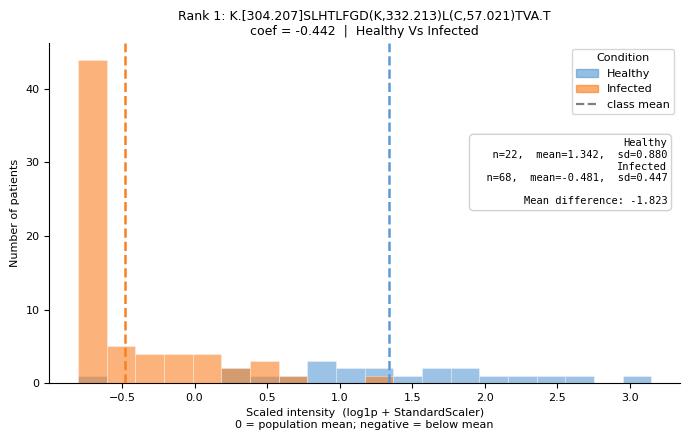

    Saved: histogram_02_K__304_207__C_57_021__C_57_021_AAADPHE_C.png


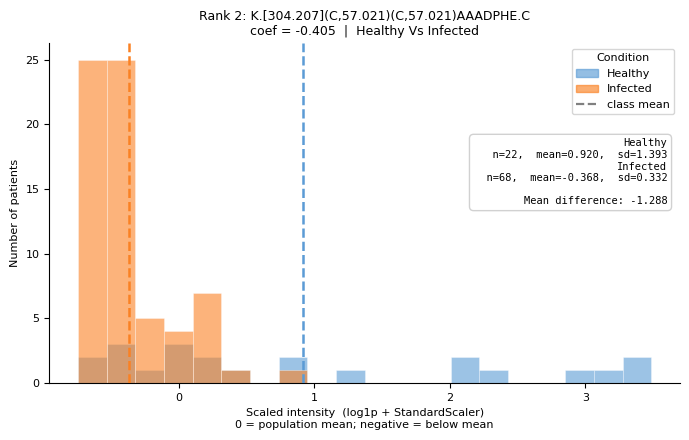

    Saved: histogram_03_D__304_207__K_203_075_SLHTLFGD_K_304_207.png


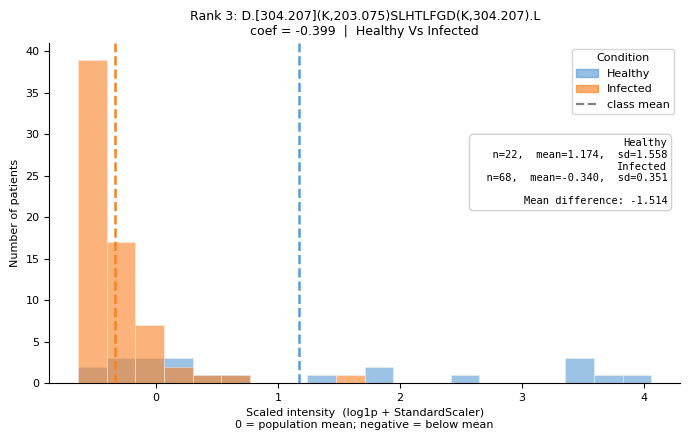

    Saved: histogram_04_K__304_207_L_K_331_18_E_C_57_021__C_57_0.png


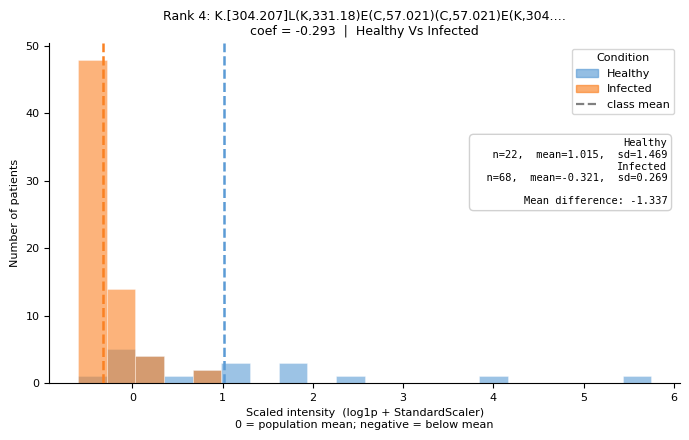

    Saved: histogram_05_K__304_207_ADSVVDLLSYNV_Q_303_212_GSGETT.png


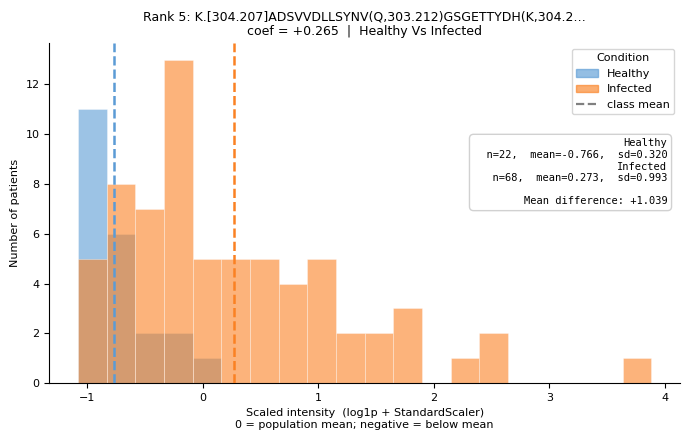

    Saved: histogram_06_S__304_207_IGYADSV_K_304_207__G.png


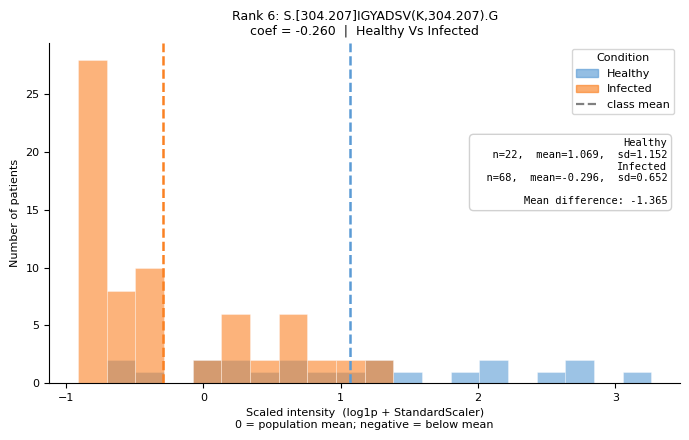

    Saved: histogram_07_R__304_207_TLADLTLLDSPI_K_304_207__V.png


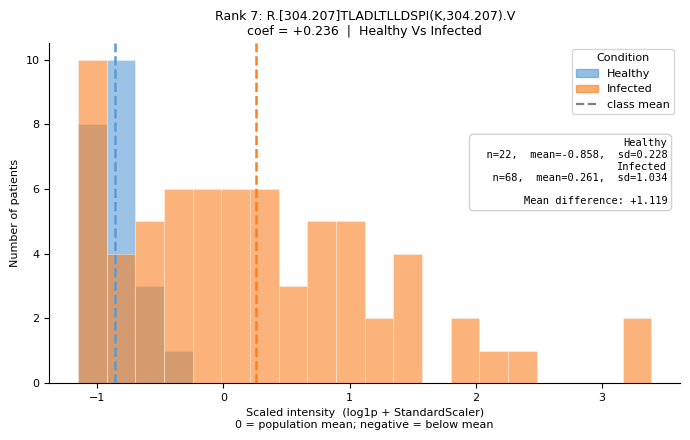

    Saved: histogram_08_K__304_207__K_376_233_VPQVSTPTLVEVSR_N.png


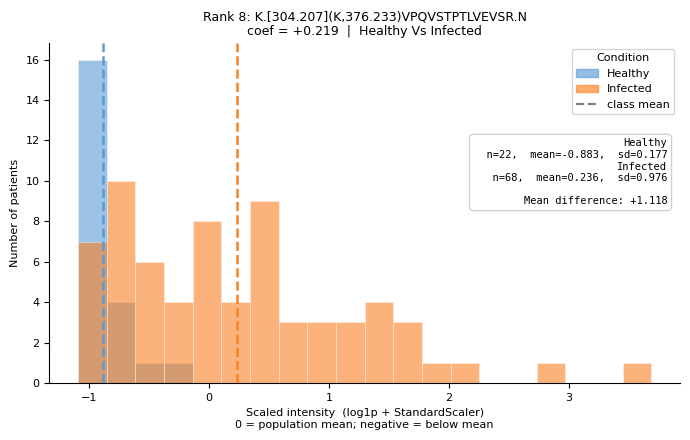

    Saved: histogram_09_S__236_123_LHTLFGD_K_304_207__L.png


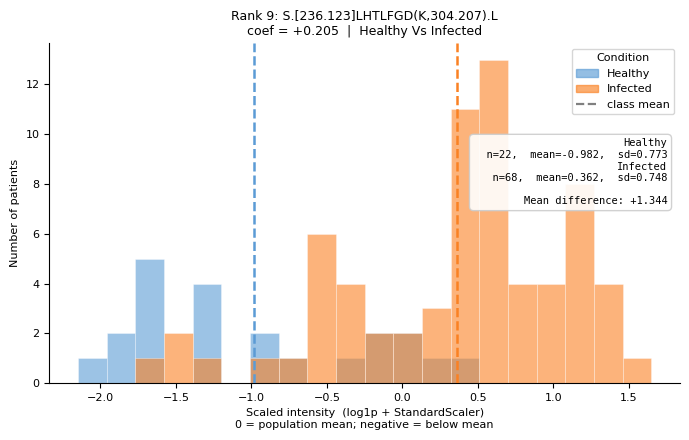

    Saved: histogram_10_F__304_207__K_291_14_DLGEENF_K_304_207__.png


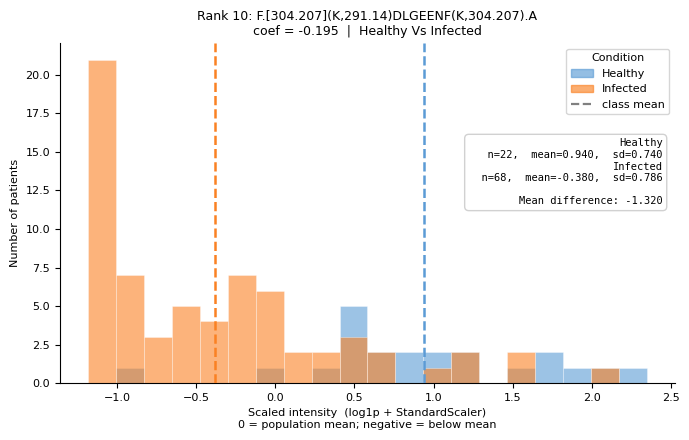

  Generating intensity heatmaps …
  Generating heatmap (missing_white) …
  Saved: feature_intensity_heatmap_missing_white.png


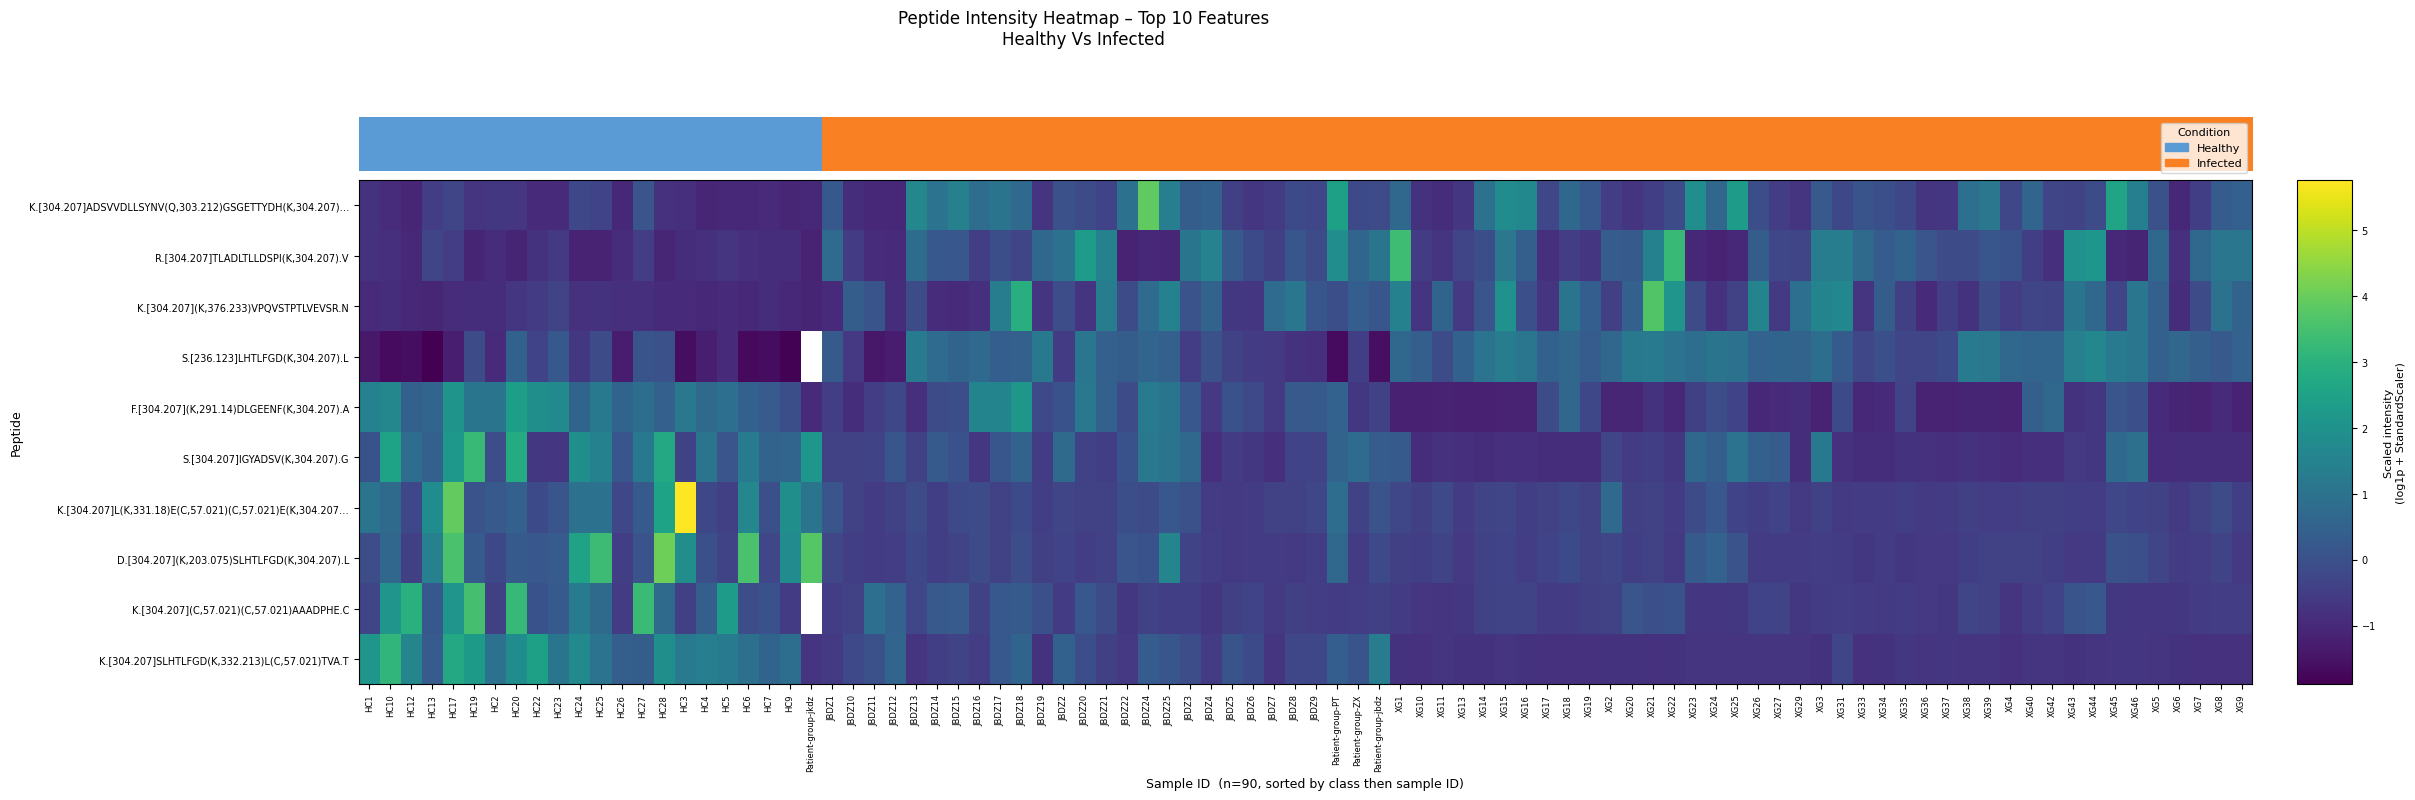

  Generating heatmap (imputed) …
  Saved: feature_intensity_heatmap_imputed.png


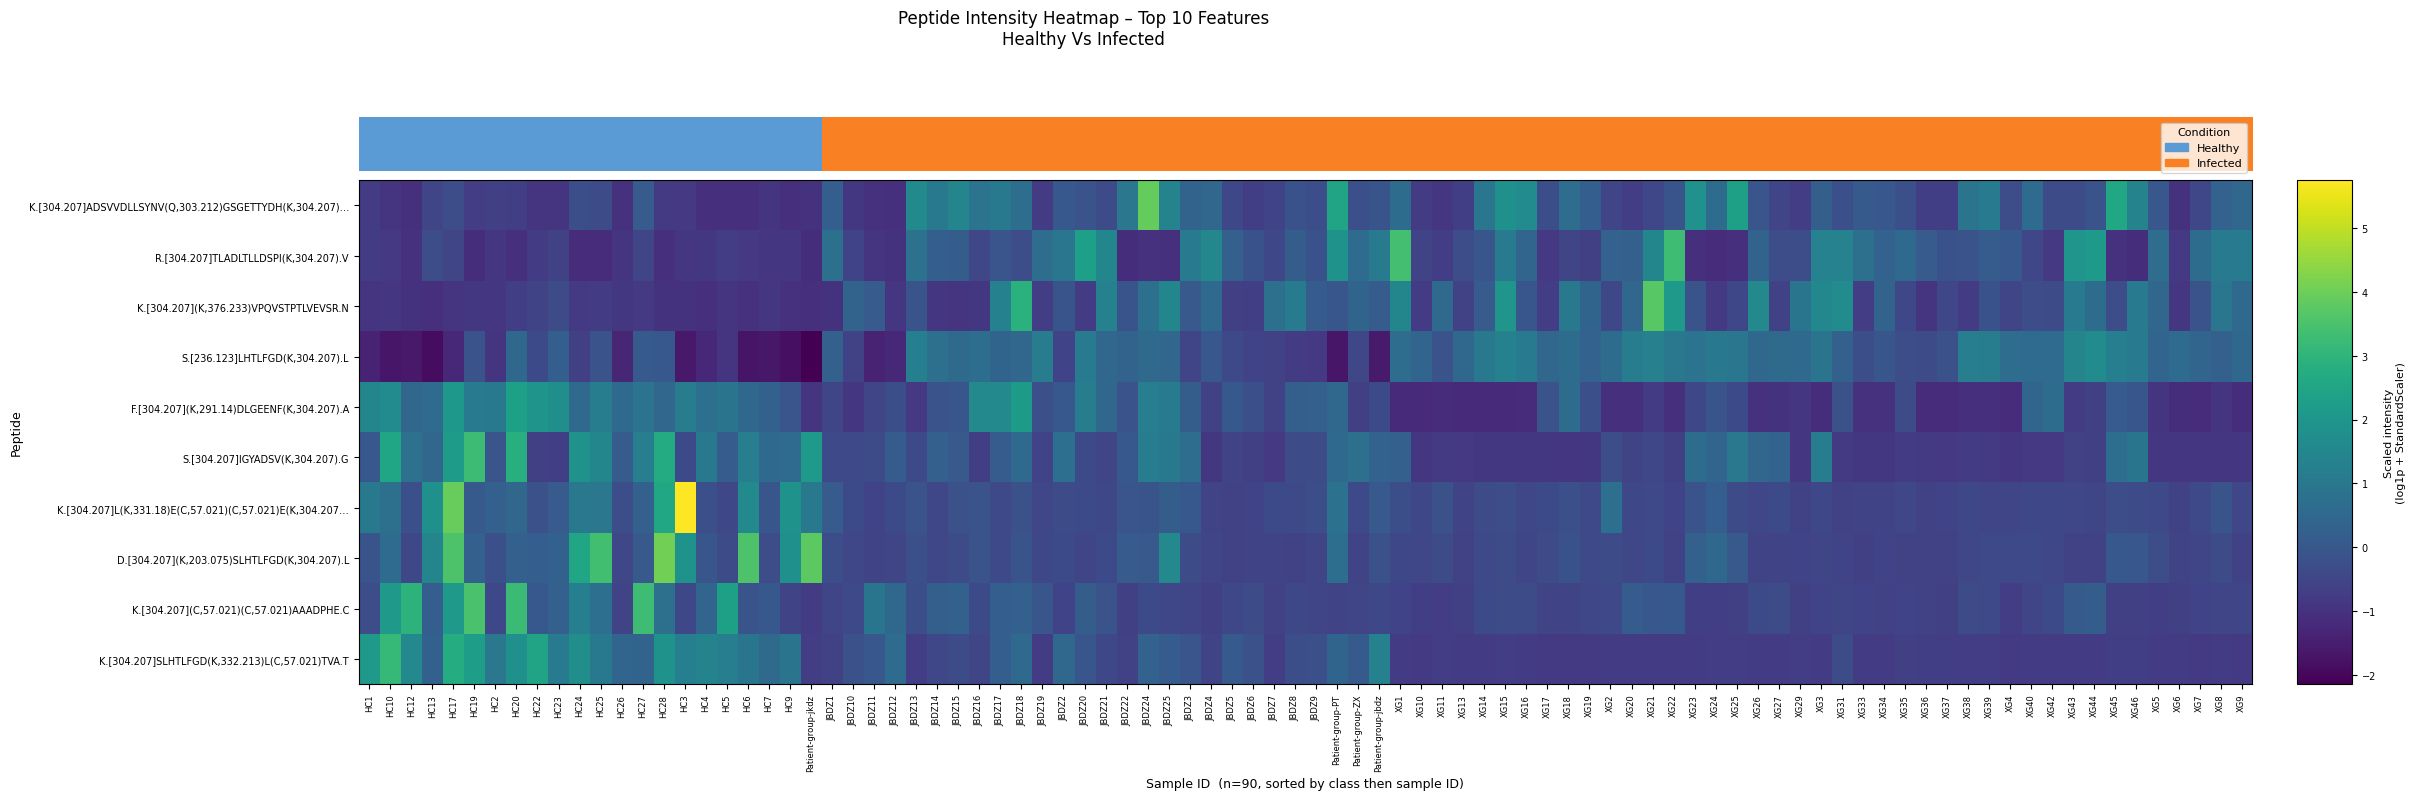


Task: symptomatic_non_covid_vs_covid
  Non-zero coefficients: 10
  Generating 10 individual histogram figures …
    Saved: histogram_01_K__304_207__C_85_056__C_57_021_TESLVNR_R.png


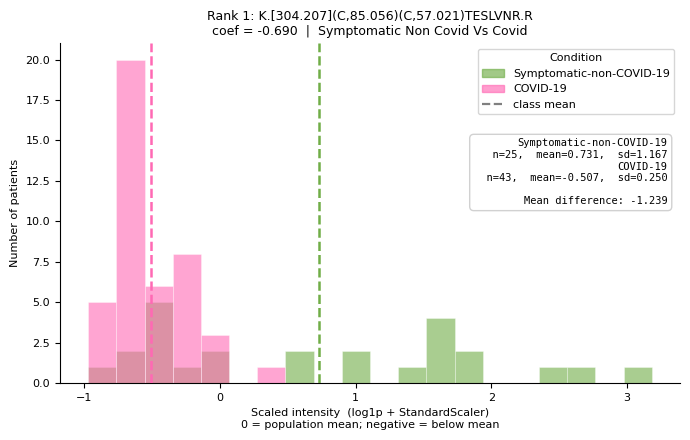

    Saved: histogram_02_K__304_207_QTALVELV_K_229_166__H.png


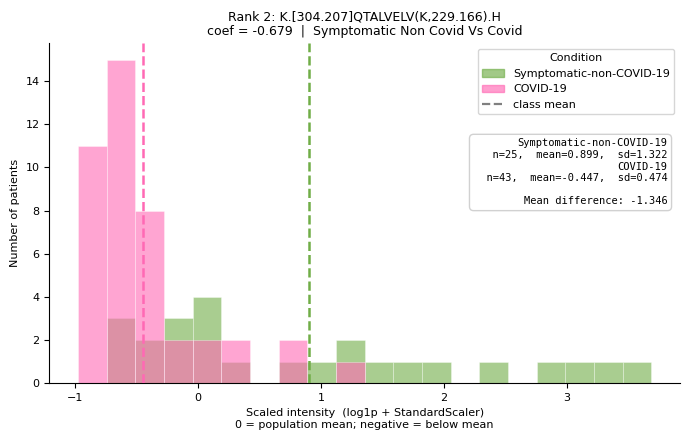

    Saved: histogram_03_K__229_166_AEFAEVS_K_304_207__L.png


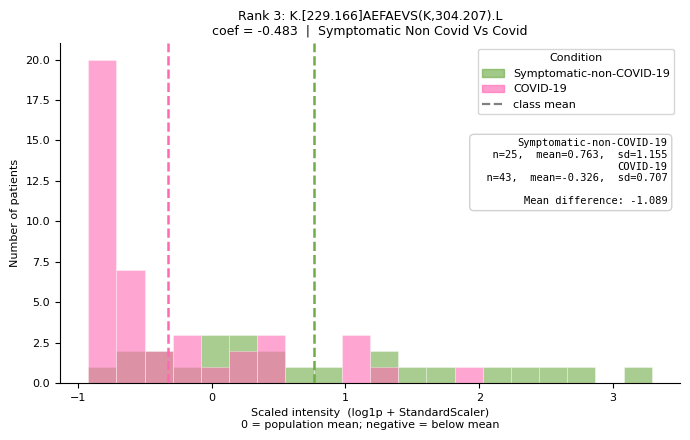

    Saved: histogram_04_R__291_173__304_207_ILGGHLDA_K_304_207__.png


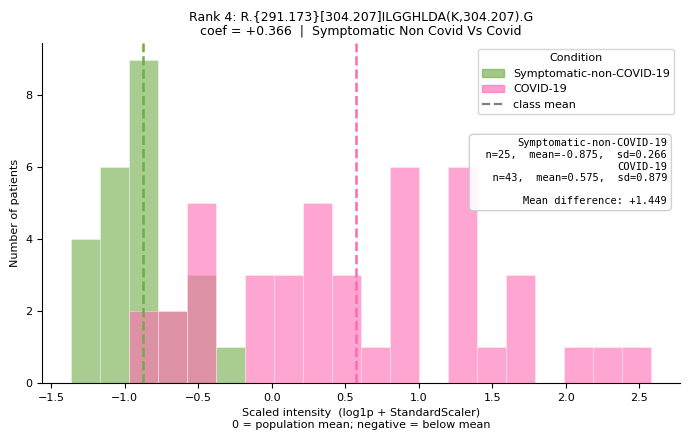

    Saved: histogram_05_K__304_207_SLHTLFGD_K_332_213_L_C_57_021.png


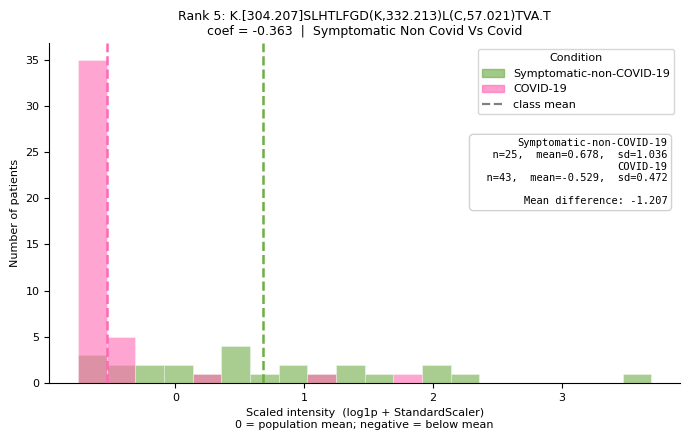

    Saved: histogram_06_K__304_207_LVD_K_304_207_FLED_V_272_169_.png


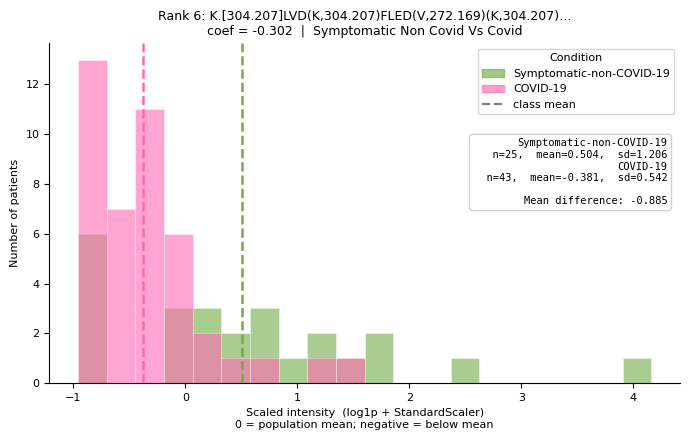

    Saved: histogram_07_R__304_207__F__57_06__K_304_207_DLGEENF_.png


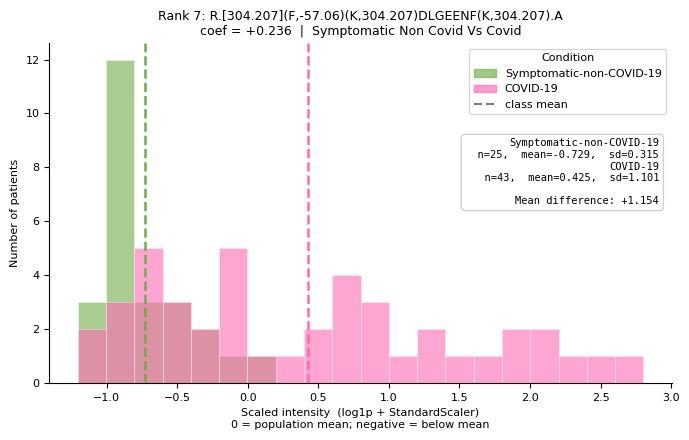

    Saved: histogram_08_K__304_207_AEFAEV_S_31_006__K_304_207__L.png


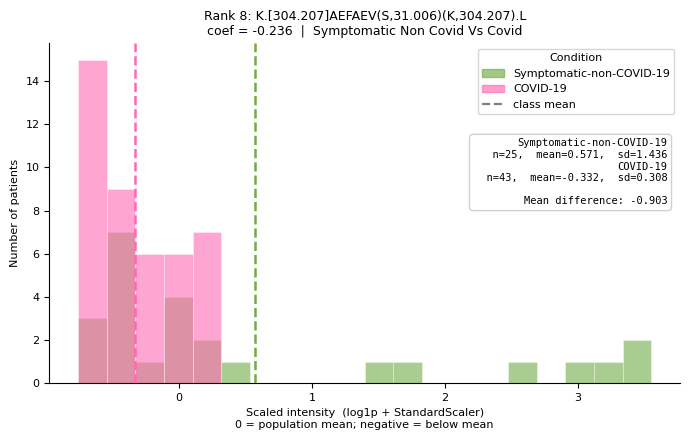

    Saved: histogram_09_K__304_207__C_57_021__C_57_021_AAADPHE_C.png


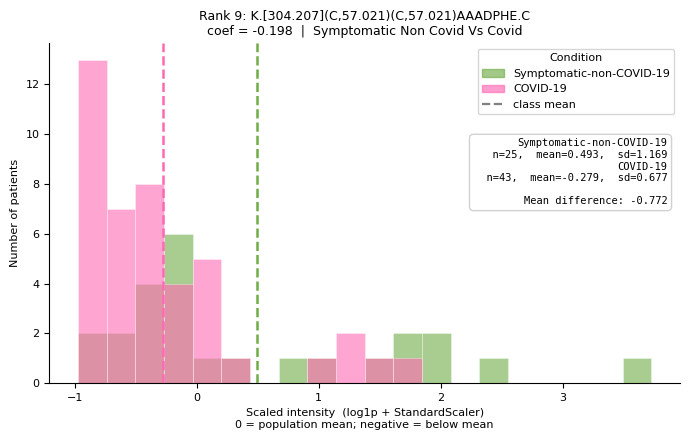

    Saved: histogram_10_K__304_207_GTV_N_49_023_LTWSRA_S.png


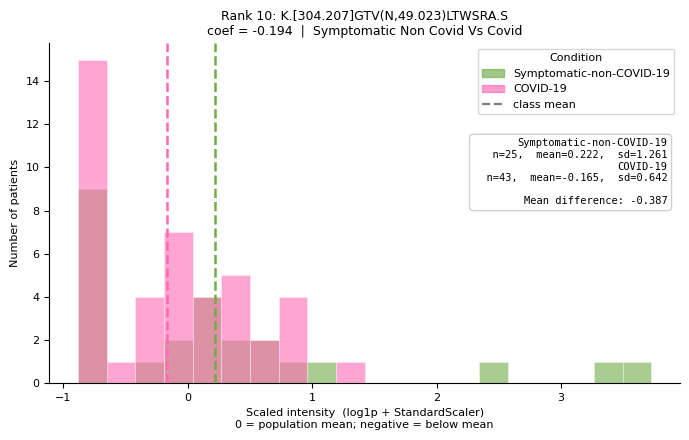

  Generating intensity heatmaps …
  Generating heatmap (missing_white) …
  Saved: feature_intensity_heatmap_missing_white.png


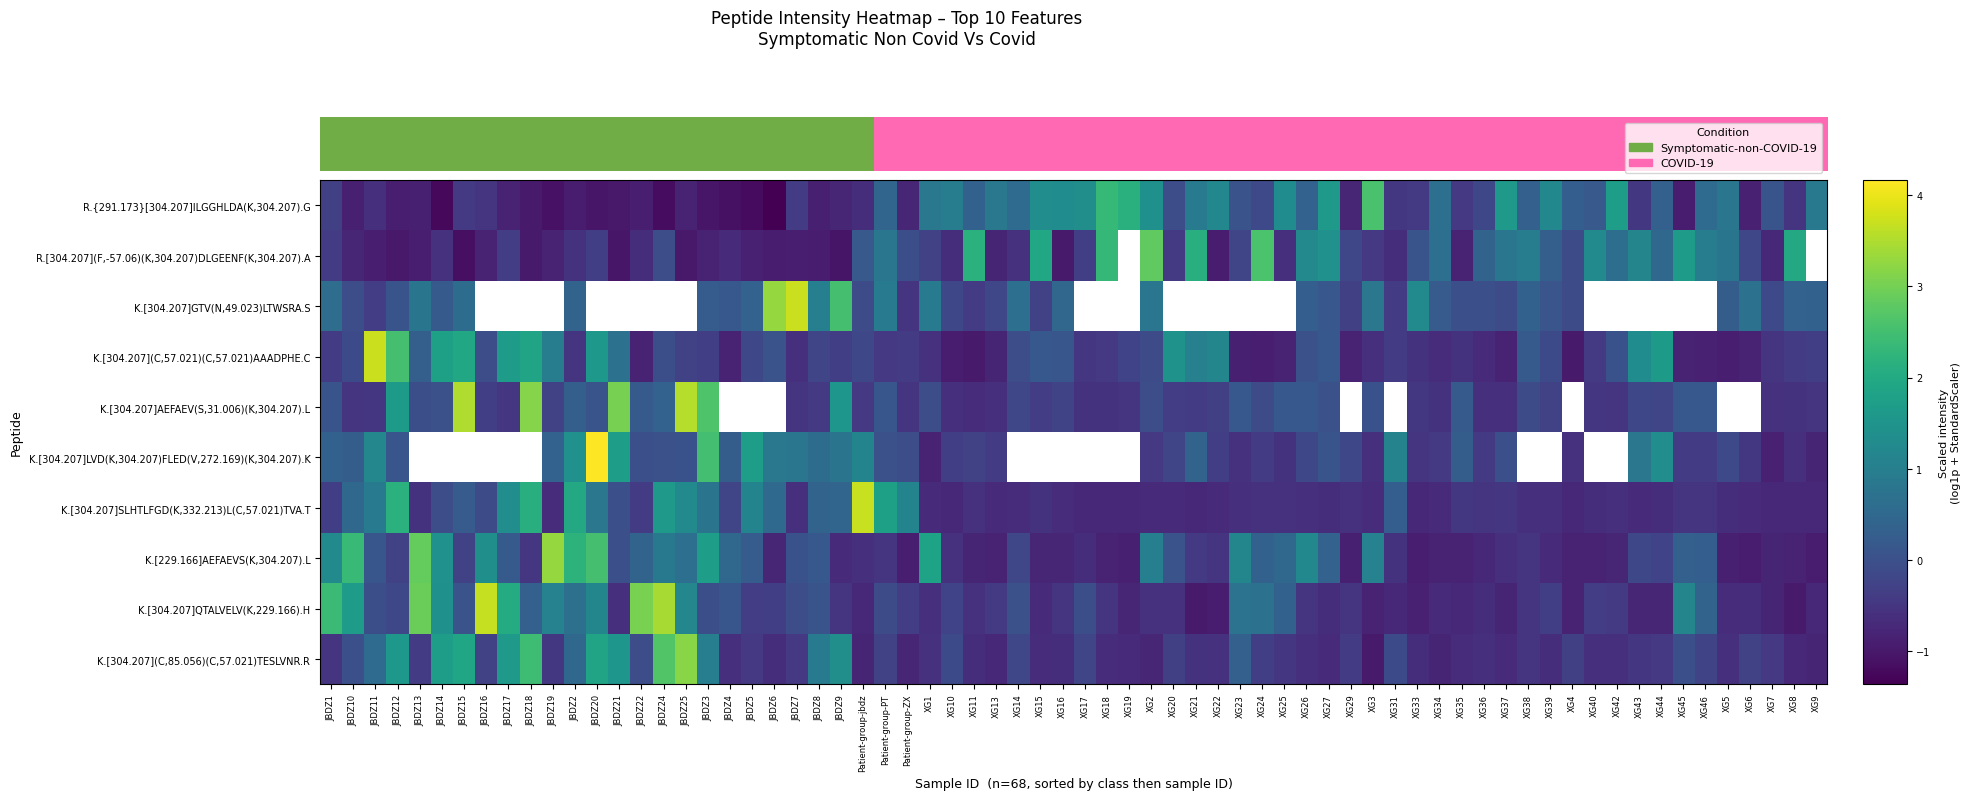

  Generating heatmap (imputed) …
  Saved: feature_intensity_heatmap_imputed.png


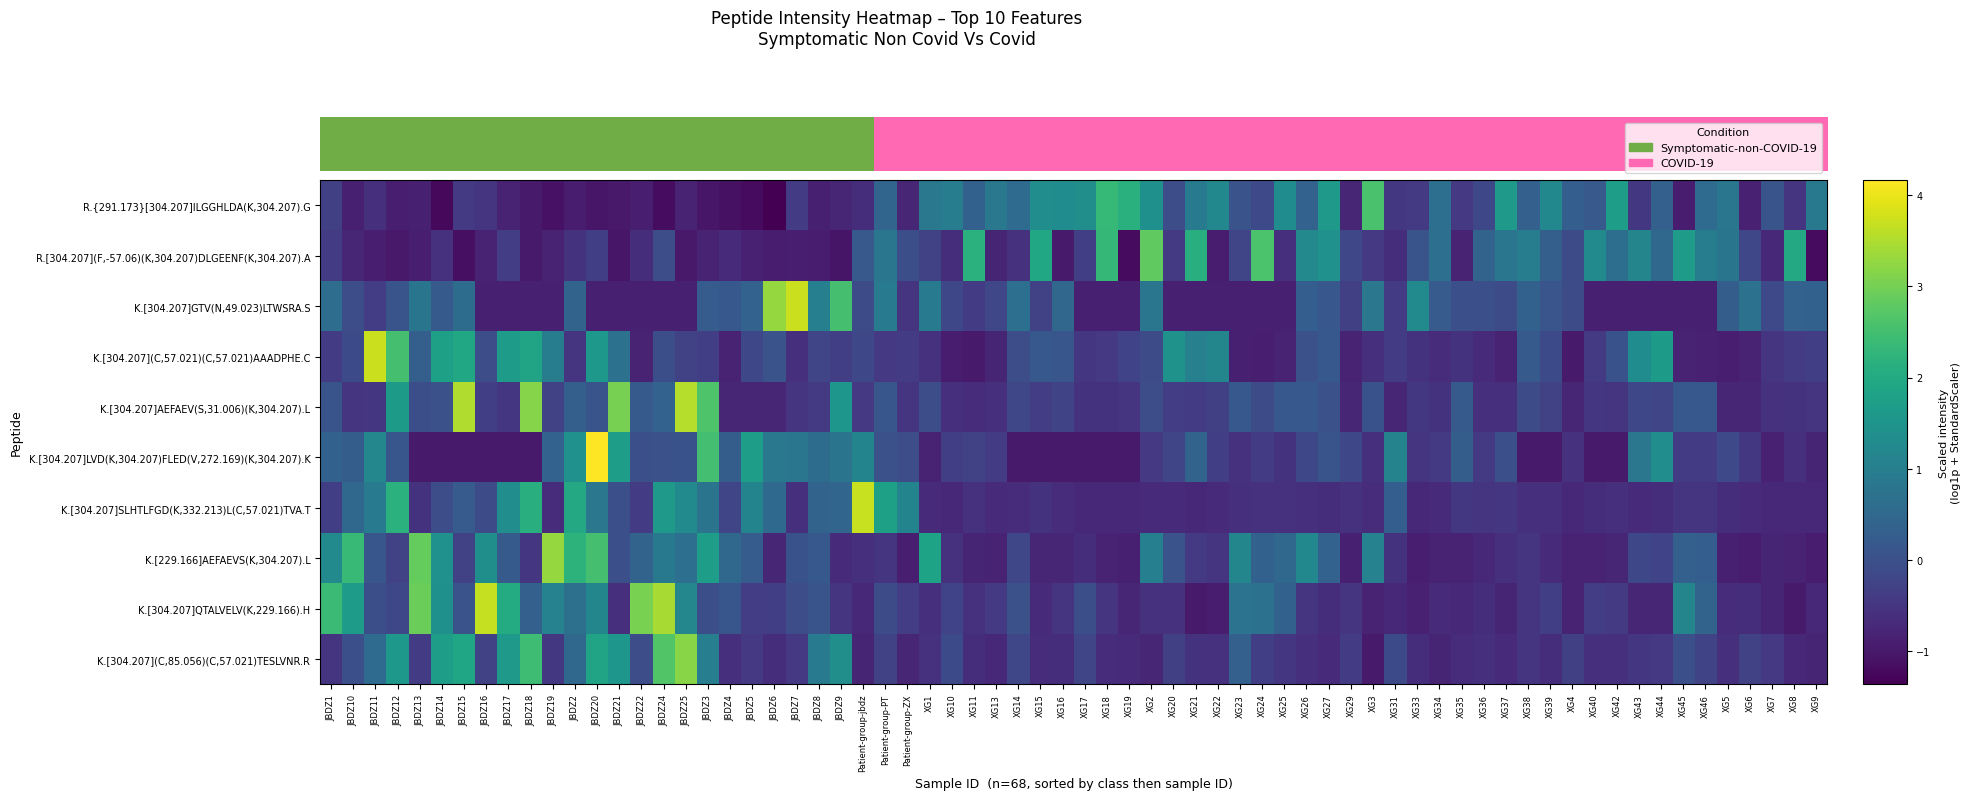


Task: severe_vs_nonsevere
  Non-zero coefficients: 10
  Generating 10 individual histogram figures …
    Saved: histogram_01_R__304_207_EANYIG_S_304_212_D_K_304_207_.png


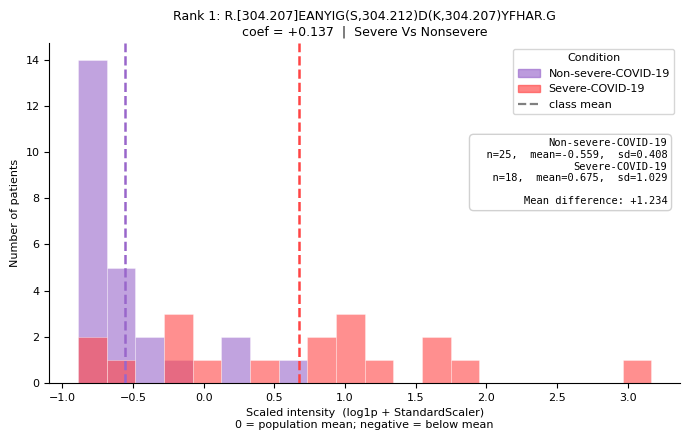

    Saved: histogram_02_R__290_173__304_207_EGT_C_57_021_PEAPTDE.png


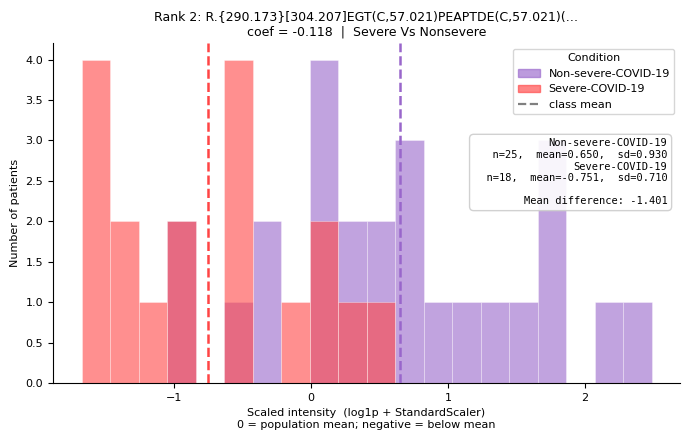

    Saved: histogram_03_R__304_207_GDAV_C_57_021_TESG_W_31_997_R.png


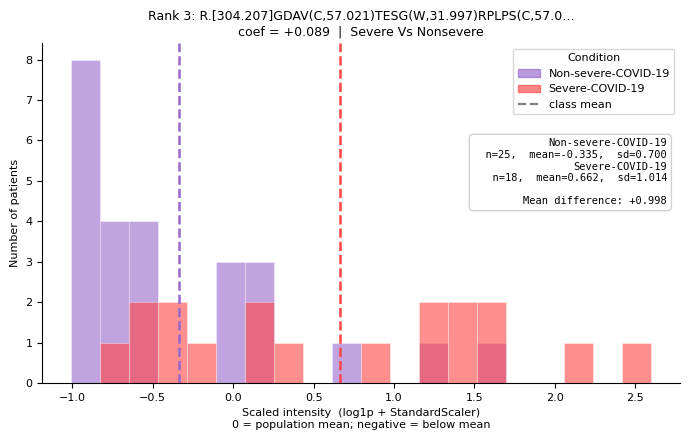

    Saved: histogram_04_K__304_207__T__13_036__C_57_021_VADESAEN.png


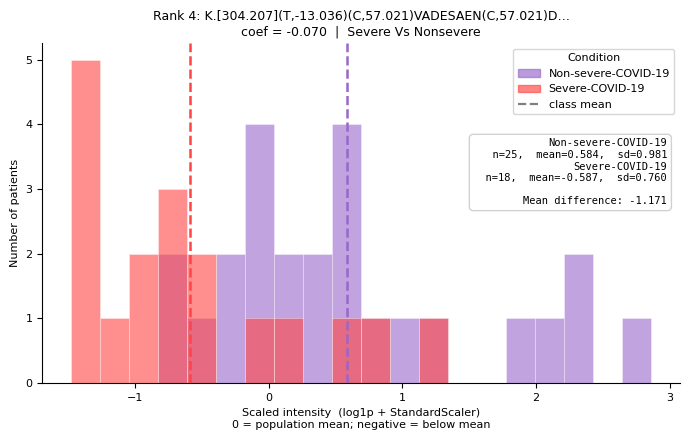

    Saved: histogram_05_K__304_207__V_290_171_DNALQSGNSQESVTEQDS.png


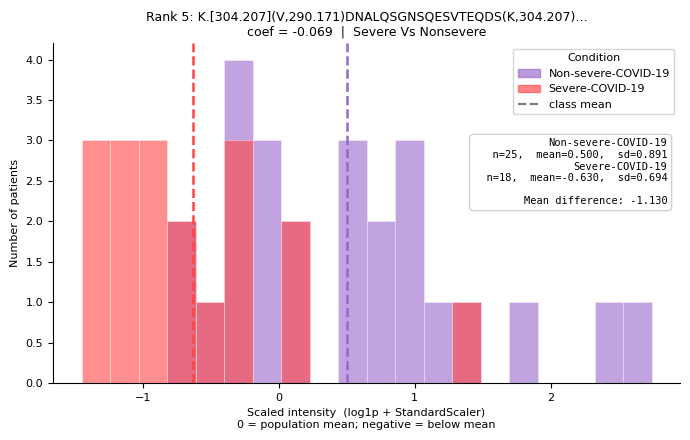

    Saved: histogram_06_R__304_207__F__13_032__K_304_207_DLGEENF.png


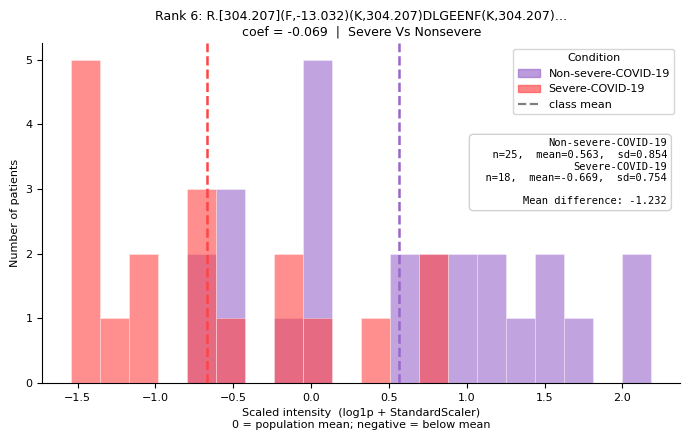

    Saved: histogram_07_N__186_070_E_C_57_021_FLQH_K_304_207_DDN.png


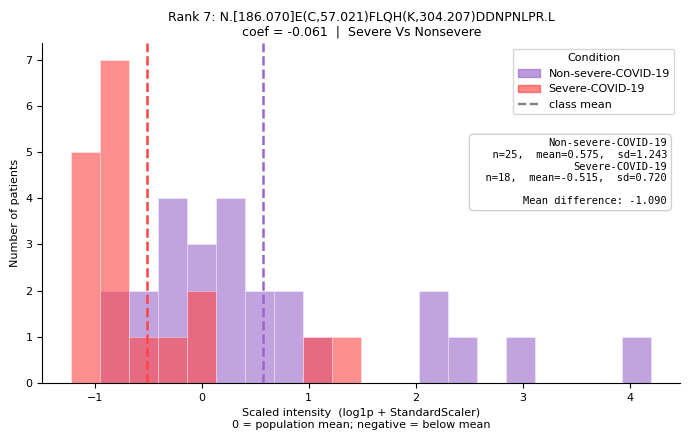

    Saved: histogram_08_R__304_207_GPGGAWAAEVISNAR_E.png


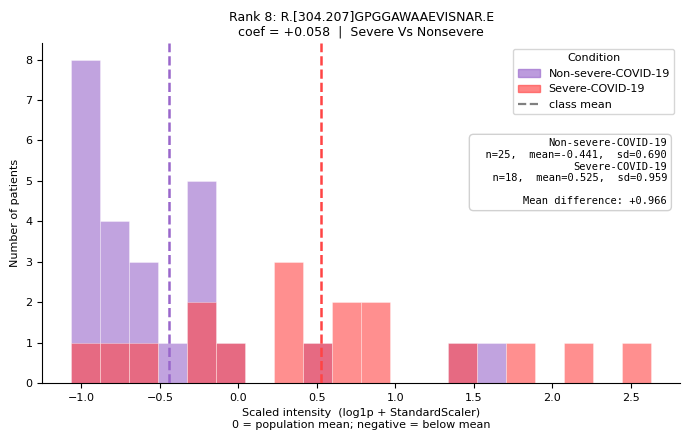

    Saved: histogram_09_R__304_207_SG_K_304_207_DPNHFRPAGLPE_K_3.png


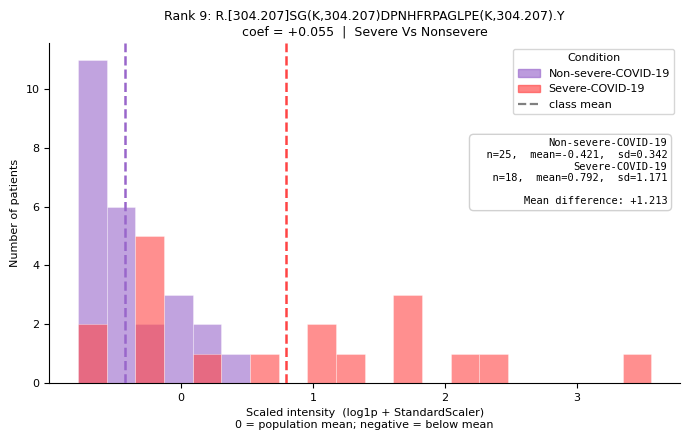

    Saved: histogram_10_K__304_207_DLLLPQPDLR_Y.png


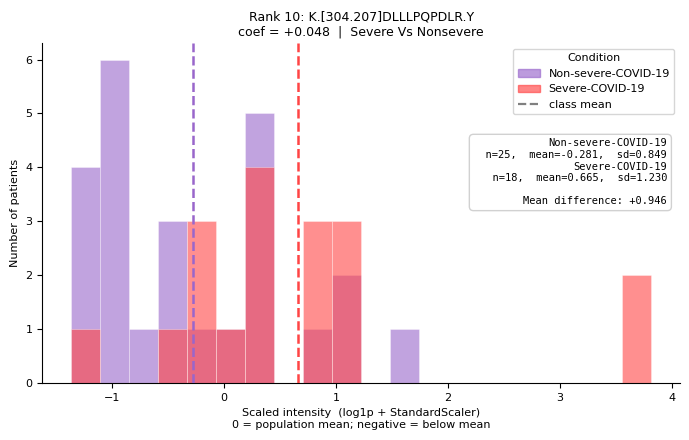

  Generating intensity heatmaps …
  Generating heatmap (missing_white) …
  Saved: feature_intensity_heatmap_missing_white.png


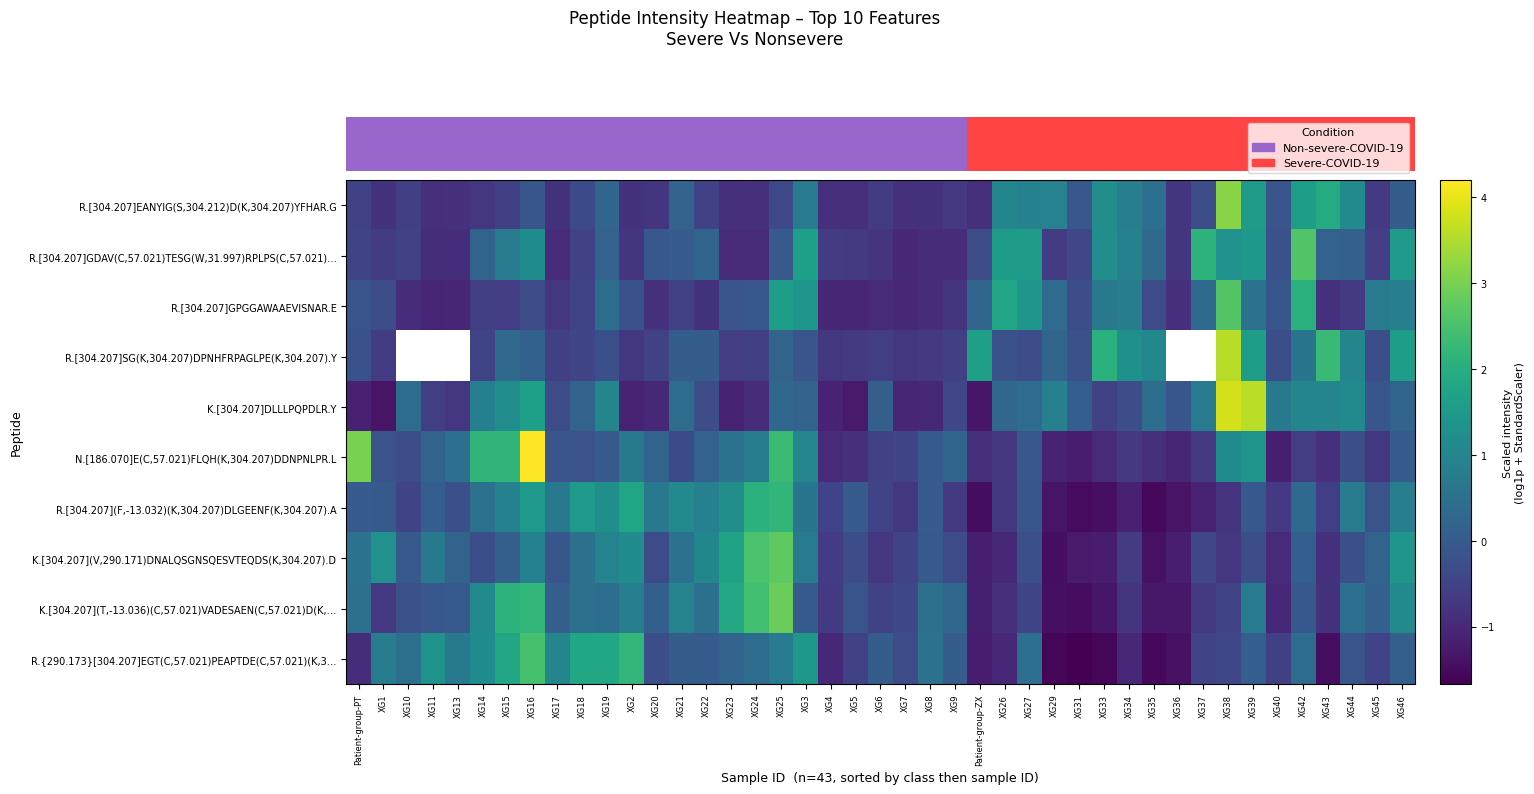

  Generating heatmap (imputed) …
  Saved: feature_intensity_heatmap_imputed.png


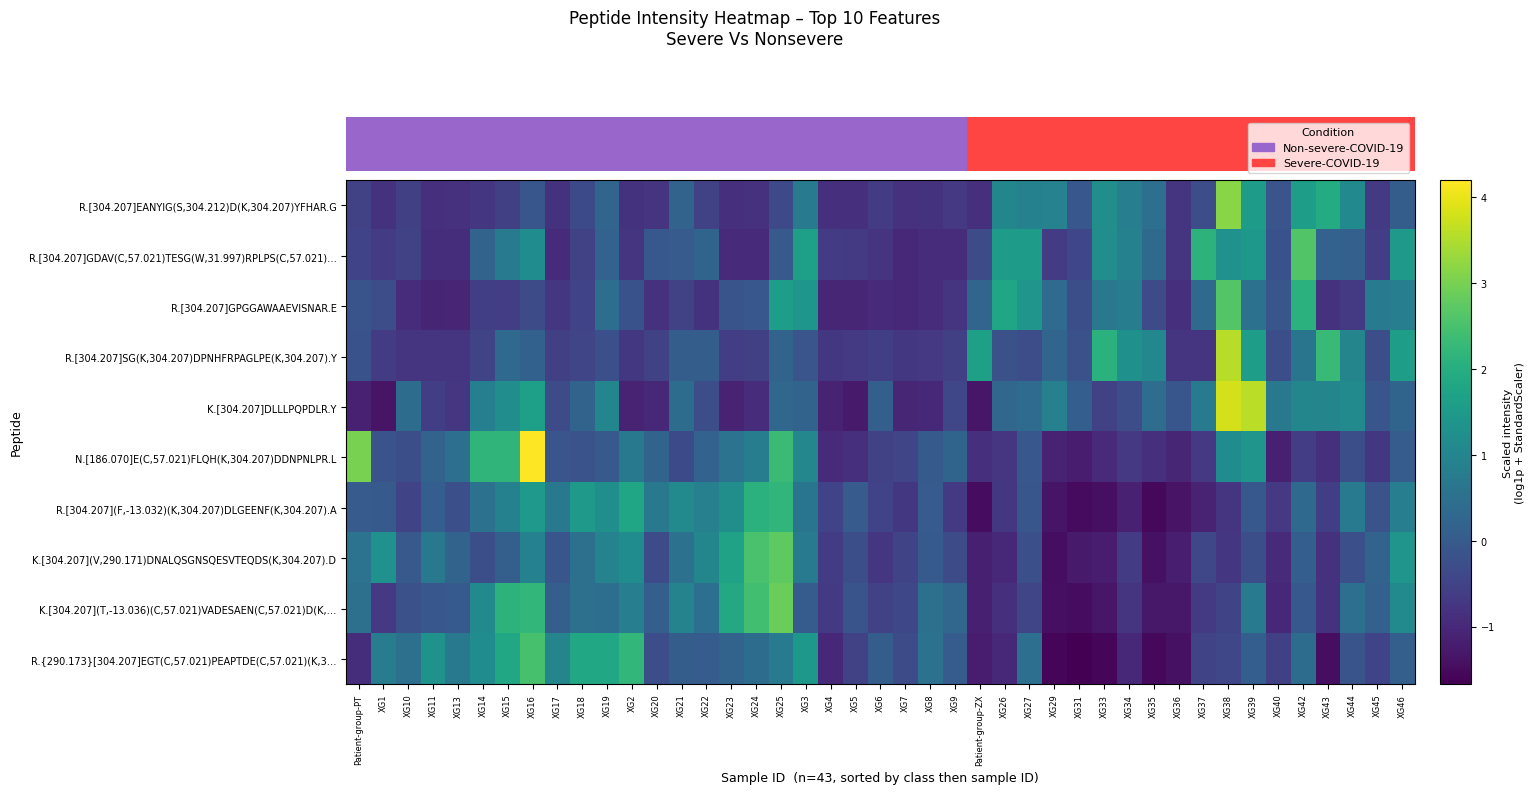


Done. All figures saved next to each task's CSV files.


In [4]:
def main() -> None:
    for task_name, cfg in TASK_CONFIGS.items():
        print(f"\n{'='*60}")
        print(f"Task: {task_name}")
        print(f"{'='*60}")
 
        data = load_task(task_name)
        n_nonzero = (data["coef_df"]["abs_coefficient"] > 0).sum()
        print(f"  Non-zero coefficients: {n_nonzero}")
        top_n = min(TOP_N_FEATURES, n_nonzero)
        if top_n == 0:
            print("  No non-zero coefficients found – skipping.")
            continue
 
        print(f"  Generating {top_n} individual histogram figures …")
        plot_intensity_histograms(
            task_name=task_name,
            X_all=data["X_all"],
            meta_all=data["meta_all"],
            coef_df=data["coef_df"],
            class_labels=cfg["class_labels"],
            palette=cfg["palette"],
            top_n=top_n,
            task_dir=data["task_dir"],
        )
 
        print("  Generating intensity heatmaps …")
        # Generate one with regular data (missing values imputed with 0), one with missing values 
        # shown as white
        for show_missing, suffix in [(True, "missing_white"), (False, "imputed")]:
            heatmap_path = data["task_dir"] / f"feature_intensity_heatmap_{suffix}.png"
            print(f"  Generating heatmap ({suffix}) …")
            plot_intensity_heatmap(
                task_name=task_name,
                X_all=data["X_all"],
                missing_all=data["missing_all"],
                meta_all=data["meta_all"],
                coef_df=data["coef_df"],
                class_labels=cfg["class_labels"],
                palette=cfg["palette"],
                top_n=top_n,
                show_missing=show_missing,
                save_path=heatmap_path,
            )
 
    print("\nDone. All figures saved next to each task's CSV files.")
 
 
if __name__ == "__main__":
    main()

## Compare to other model top coefficients 

Actually after looking at the results they don't match up super closely so maybe we don't use any of this

I looked into it because we talked in our report about looking at top features across models, but it's not listed anywhere in the rubric or anything 

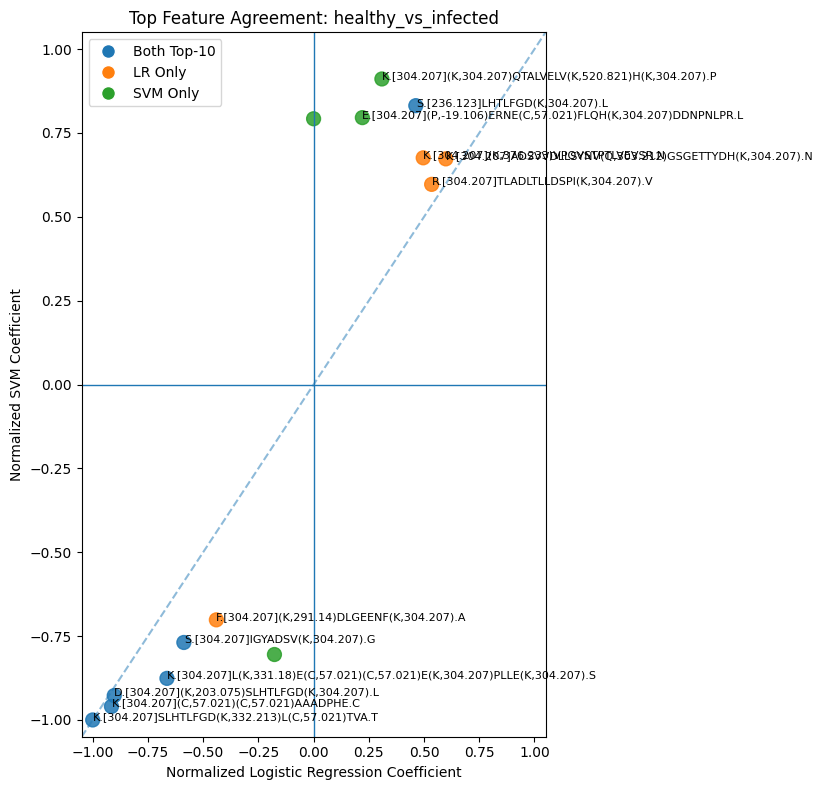

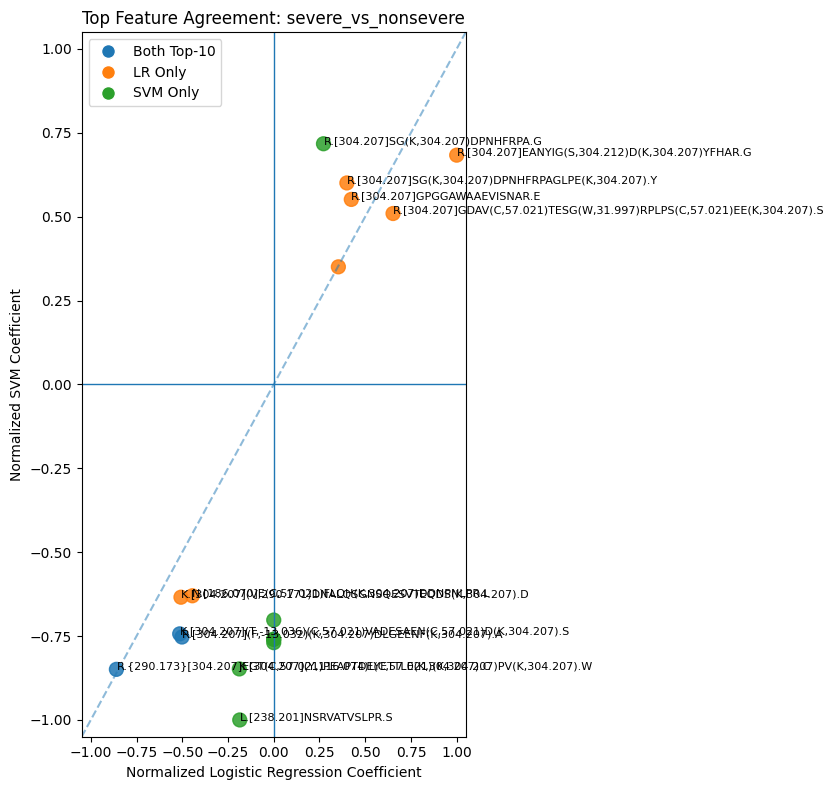

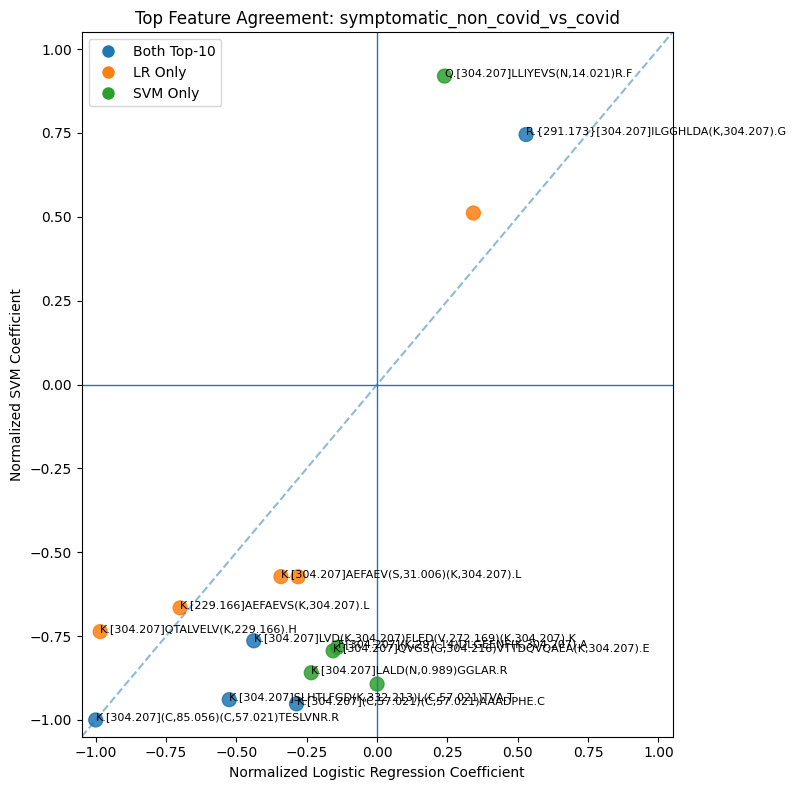

In [15]:
import pandas as pd
from matplotlib.lines import Line2D

# -----------------------------
# Load data
# -----------------------------

TOP_K = 10

tasks = ["healthy_vs_infected", "severe_vs_nonsevere", "symptomatic_non_covid_vs_covid"]

for task in tasks:
    lr = pd.read_csv(f"data/processed/{task}/logistic_regression_top_coefficients.csv")
    svm = pd.read_csv(f"data/processed/{task}/svm_top_coefficients.csv")

    lr_task = lr[lr["task"] == task].copy()
    svm_task = svm[svm["task"] == task].copy()

    # Top-k features
    lr_top = lr_task.nlargest(TOP_K, "abs_coefficient")
    svm_top = svm_task.nlargest(TOP_K, "abs_coefficient")

    lr_set = set(lr_top["peptide"])
    svm_set = set(svm_top["peptide"])

    union_features = lr_set | svm_set

    # Merge coefficients
    merged = pd.merge(
        lr_task[["peptide", "coefficient"]],
        svm_task[["peptide", "coefficient"]],
        on="peptide",
        suffixes=("_lr", "_svm")
    )

    merged = merged[merged["peptide"].isin(union_features)].copy()

    # Normalize coefficients
    merged["coef_lr_norm"] = (
        merged["coefficient_lr"] /
        merged["coefficient_lr"].abs().max()
    )

    merged["coef_svm_norm"] = (
        merged["coefficient_svm"] /
        merged["coefficient_svm"].abs().max()
    )

    # Category for coloring
    def get_category(peptide):
        if peptide in lr_set and peptide in svm_set:
            return "Both"
        elif peptide in lr_set:
            return "LR only"
        else:
            return "SVM only"

    merged["category"] = merged["peptide"].apply(get_category)

    color_map = {
        "Both": "tab:blue",
        "LR only": "tab:orange",
        "SVM only": "tab:green"
    }

    merged["color"] = merged["category"].map(color_map)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8, 8))

    plt.scatter(
        merged["coef_lr_norm"],
        merged["coef_svm_norm"],
        c=merged["color"],
        s=100,
        alpha=0.85
    )

    # Label strongest points
    merged["strength"] = (
        merged["coef_lr_norm"].abs() +
        merged["coef_svm_norm"].abs()
    )

    top_labels = merged.nlargest(12, "strength")

    for _, row in top_labels.iterrows():
        plt.text(
            row["coef_lr_norm"],
            row["coef_svm_norm"],
            row["peptide"],
            fontsize=8
        )

    # Reference lines
    lim = 1.05

    plt.plot(
        [-lim, lim],
        [-lim, lim],
        linestyle="--",
        alpha=0.5
    )

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)

    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.xlabel("Normalized Logistic Regression Coefficient")
    plt.ylabel("Normalized SVM Coefficient")

    plt.title(f"Top Feature Agreement: {task}")

    # Legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='Both Top-10',
            markerfacecolor='tab:blue',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='LR Only',
            markerfacecolor='tab:orange',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='SVM Only',
            markerfacecolor='tab:green',
            markersize=10
        )
    ]

    plt.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

Saved: data/processed/healthy_vs_infected/bump_chart_lr_svm.png


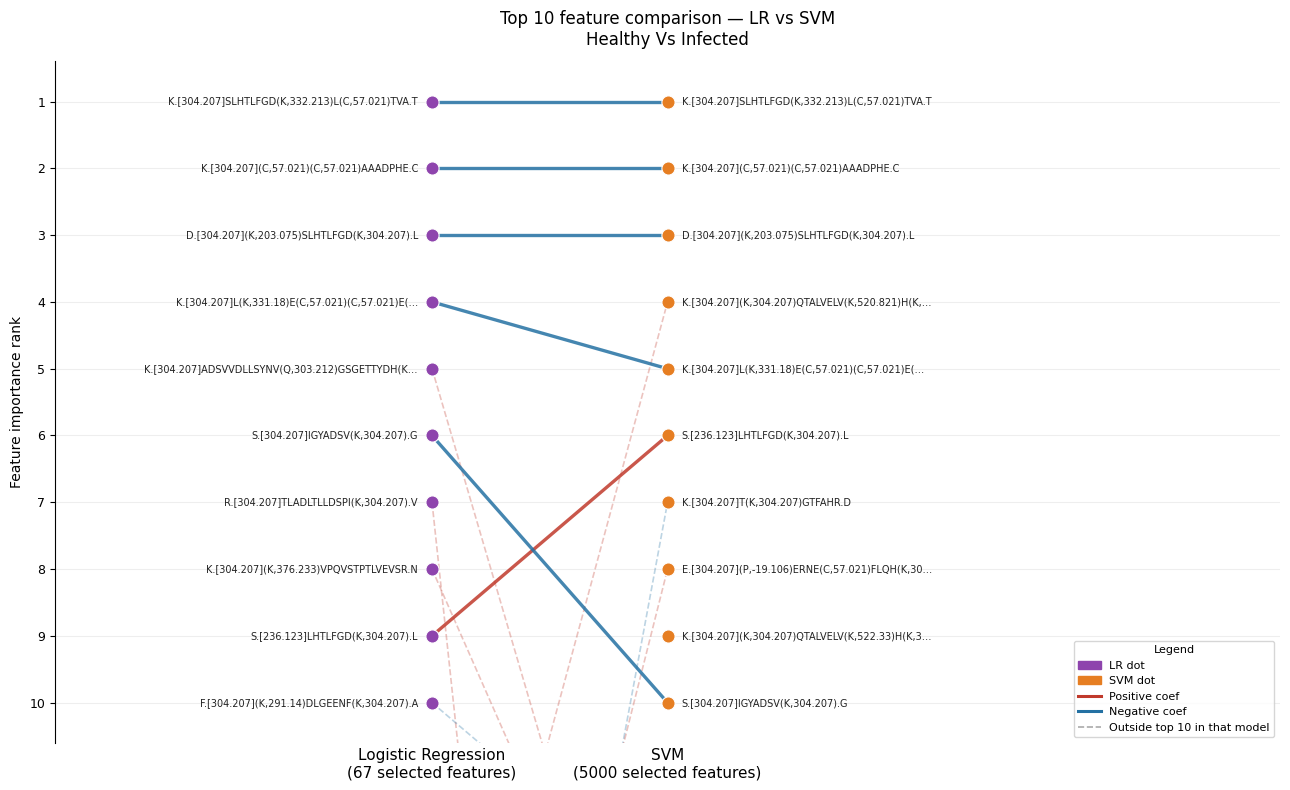

Saved: data/processed/severe_vs_nonsevere/bump_chart_lr_svm.png


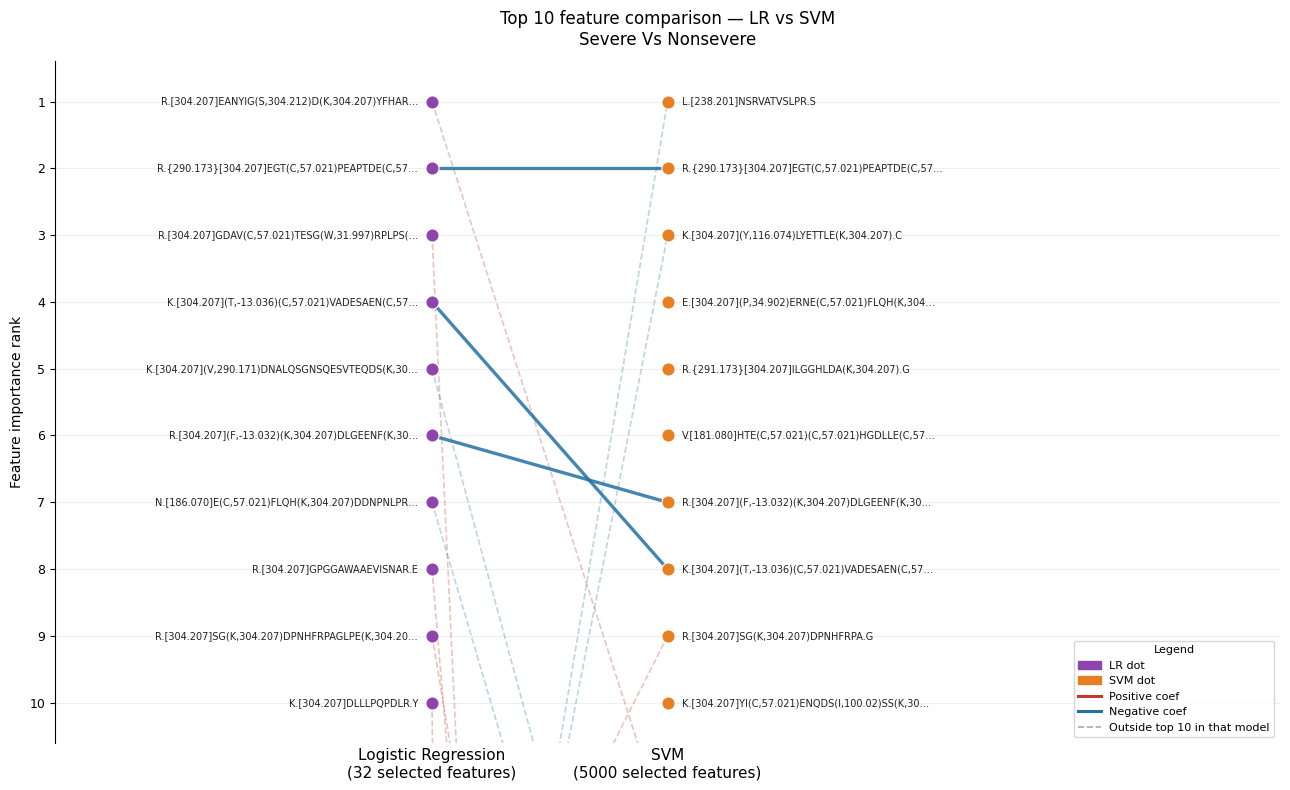

Saved: data/processed/symptomatic_non_covid_vs_covid/bump_chart_lr_svm.png


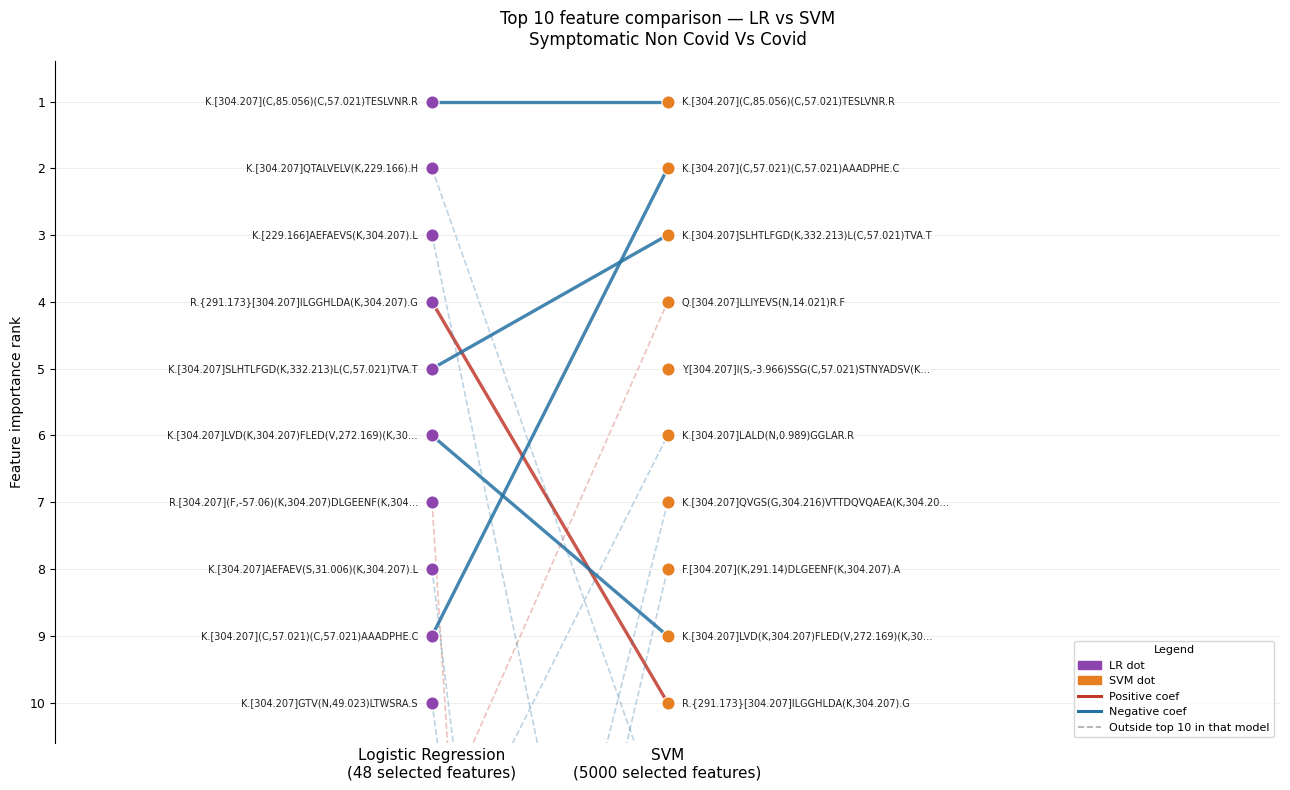

In [16]:
"""
bump_chart_lr_svm_xgb.py
─────────────────────────
Bump chart comparing the top-10 features from:
  Logistic Regression (LR), SVM

Lines connect the same peptide across model lanes.
Line color = coefficient sign for LR/SVM (red = positive, blue = negative)

Output:
  bump_chart_lr_svm.png
"""

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd


for task_name in ["healthy_vs_infected", "severe_vs_nonsevere", "symptomatic_non_covid_vs_covid"]:
    LR_CSV = Path(f"data/processed/{task_name}/logistic_regression_top_coefficients.csv")
    SVM_CSV = Path(f"data/processed/{task_name}/svm_top_coefficients.csv")
    XGB_CSV = Path(f"data/processed/{task_name}/xgboost_nonlinear_feature_importance_gain.csv")
    TASK = task_name

    TOP_N = 10
    LABEL_MAX = 46    # max chars for peptide labels before truncating

    POS_COLOR = "#c0392b" # red  — positive coef 
    NEG_COLOR = "#2471a3" # blue — negative coef 
    GREY_COLOR = "#888888" # misc

    MODEL_DOT_COLORS = {"LR": "#8e44ad", "SVM": "#e67e22"}

    # Helpers

    def shorten(name, n=LABEL_MAX):
        return name if len(name) <= n else name[:n - 1] + "…"

    def load_lr_svm(path, task):
        df = pd.read_csv(path)
        df = (df[df["task"] == task]
            .query("abs_coefficient > 0")
            .sort_values("abs_coefficient", ascending=False)
            .reset_index(drop=True))
        df["rank"] = df.index + 1
        return df[["peptide", "coefficient", "rank"]]

    # Load data 

    models = {
        "LR":  load_lr_svm(LR_CSV,  TASK),
        "SVM": load_lr_svm(SVM_CSV, TASK),
    }

    # x position for each model lane
    X = {"LR": 0, "SVM": 1}

    # Build peptide → {model: (rank, coef)} for all peptides in any top-10
    top_peps = set()
    for df in models.values():
        top_peps |= set(df.head(TOP_N)["peptide"])

    pep_info = {}
    for mname, df in models.items():
        for _, row in df.iterrows():
            p = row["peptide"]
            if p not in pep_info:
                pep_info[p] = {}
            pep_info[p][mname] = (row["rank"], row["coefficient"])

    # Figure 

    fig, ax = plt.subplots(figsize=(13, 8))

    for peptide in top_peps:
        info = pep_info[peptide]

        # Sign color from LR, fall back to SVM, else grey
        if "LR" in info and pd.notna(info["LR"][1]):
            lcolor = POS_COLOR if info["LR"][1] > 0 else NEG_COLOR
        elif "SVM" in info and pd.notna(info["SVM"][1]):
            lcolor = POS_COLOR if info["SVM"][1] > 0 else NEG_COLOR
        else:
            lcolor = GREY_COLOR

        # Draw connecting lines between adjacent model pairs
        model_order = [m for m in ["LR", "SVM"] if m in info]
        for i in range(len(model_order) - 1):
            m1, m2 = model_order[i], model_order[i + 1]
            r1, r2 = info[m1][0], info[m2][0]
            # Solid + opaque if both endpoints are within top-N, dashed + faint if not
            in_top = r1 <= TOP_N and r2 <= TOP_N
            ax.plot(
                [X[m1], X[m2]], [r1, r2],
                color=lcolor,
                lw=2.4 if in_top else 1.2,
                alpha=0.85 if in_top else 0.3,
                linestyle="-" if in_top else "--",
                solid_capstyle="round",
                zorder=2,
            )

        # Dots and labels at each lane
        for mname, (rank, _) in info.items():
            if rank > TOP_N:
                continue
            ax.scatter(X[mname], rank,
                    color=MODEL_DOT_COLORS[mname],
                    s=90, zorder=4,
                    edgecolors="white", linewidths=0.8)

            label = shorten(peptide)
            if mname == "LR":
                ax.text(X[mname] - 0.06, rank, label,
                        ha="right", va="center", fontsize=7, color="#222222")
            elif mname == "SVM":
                ax.text(X[mname] + 0.06, rank, label,
                        ha="left", va="center", fontsize=7, color="#222222")

    # Axes & styling 

    ax.set_xlim(-1.6, 3.6)
    ax.set_ylim(TOP_N + 0.6, 0.4)   # rank 1 at top

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f"Logistic Regression\n({len(models['LR'])} selected features)",
        f"SVM\n({len(models['SVM'])} selected features)"],
        fontsize=11,
    )
    ax.set_yticks(range(1, TOP_N + 1))
    ax.set_yticklabels(range(1, TOP_N + 1), fontsize=9)
    ax.set_ylabel("Feature importance rank", fontsize=10)
    ax.set_title(
        f"Top {TOP_N} feature comparison — LR vs SVM\n"
        f"{TASK.replace('_', ' ').title()}",
        fontsize=12, pad=12,
    )

    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.tick_params(axis="x", length=0)

    # Light horizontal grid lines
    for y in range(1, TOP_N + 1):
        ax.axhline(y, color="#eeeeee", lw=0.8, zorder=0)

    # Legend
    legend_els = [
        mpatches.Patch(color=MODEL_DOT_COLORS["LR"],  label="LR dot"),
        mpatches.Patch(color=MODEL_DOT_COLORS["SVM"], label="SVM dot"),
        mlines.Line2D([], [], color=POS_COLOR,  lw=2.2, label="Positive coef"),
        mlines.Line2D([], [], color=NEG_COLOR,  lw=2.2, label="Negative coef"),
        mlines.Line2D([], [], color="#aaaaaa",  lw=1.2, ls="--", label="Outside top 10 in that model"),
    ]
    ax.legend(handles=legend_els, fontsize=8, loc="lower right",
            frameon=True, title="Legend", title_fontsize=8)

    plt.tight_layout()

    out = Path(f"data/processed/{task_name}/bump_chart_lr_svm.png")
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white", edgecolor="white")
    print(f"Saved: {out}")
    plt.show()
    plt.close(fig)

Saved: data/processed/healthy_vs_infected/compare_top_feats_bar_lr_svm.png


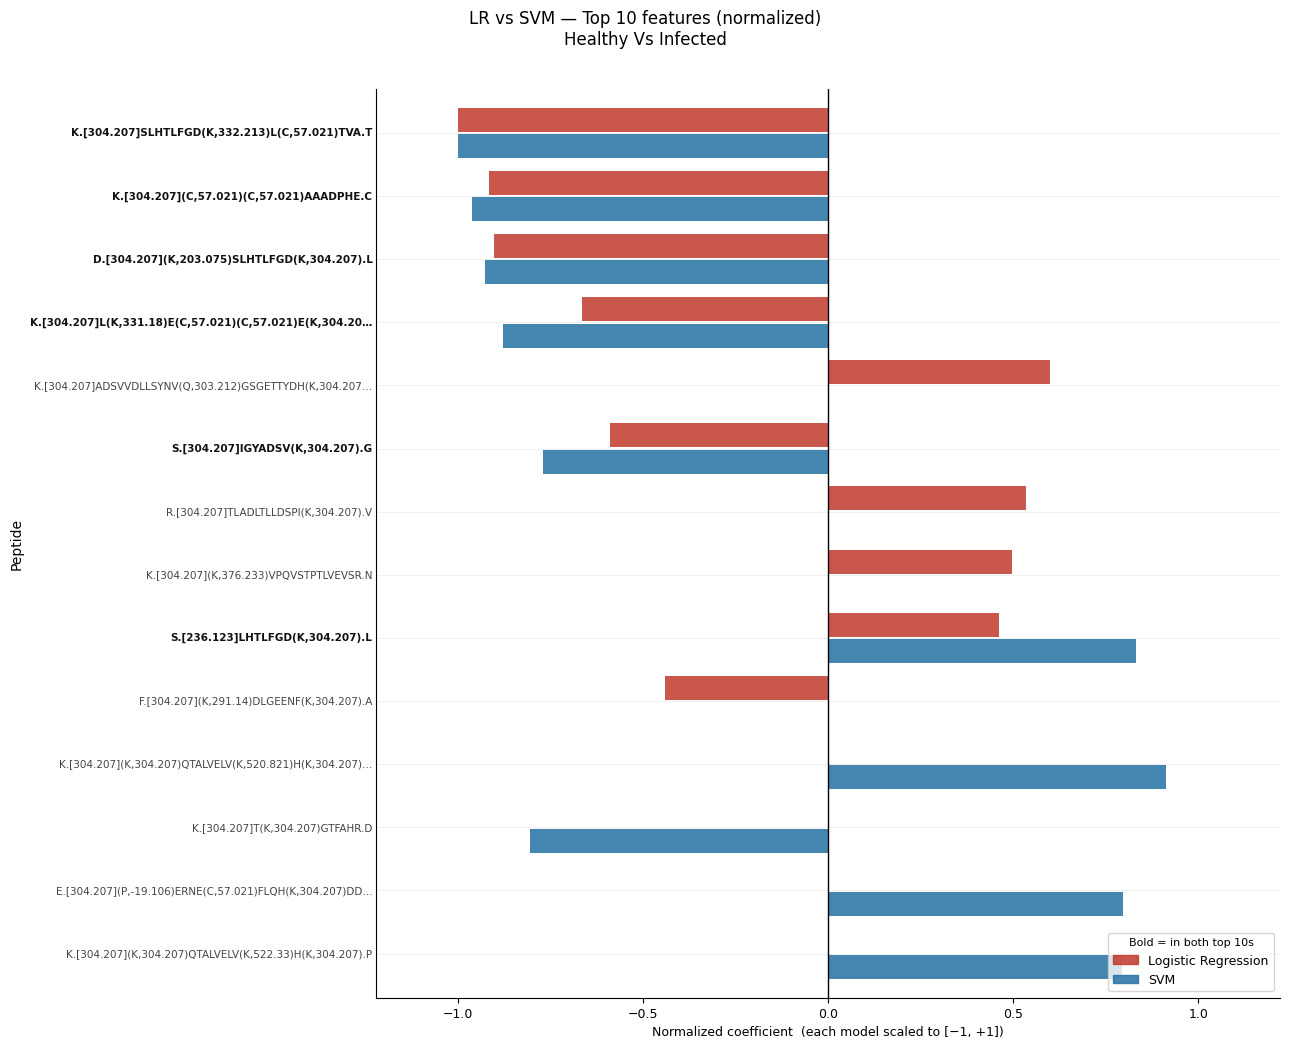

Saved: data/processed/severe_vs_nonsevere/compare_top_feats_bar_lr_svm.png


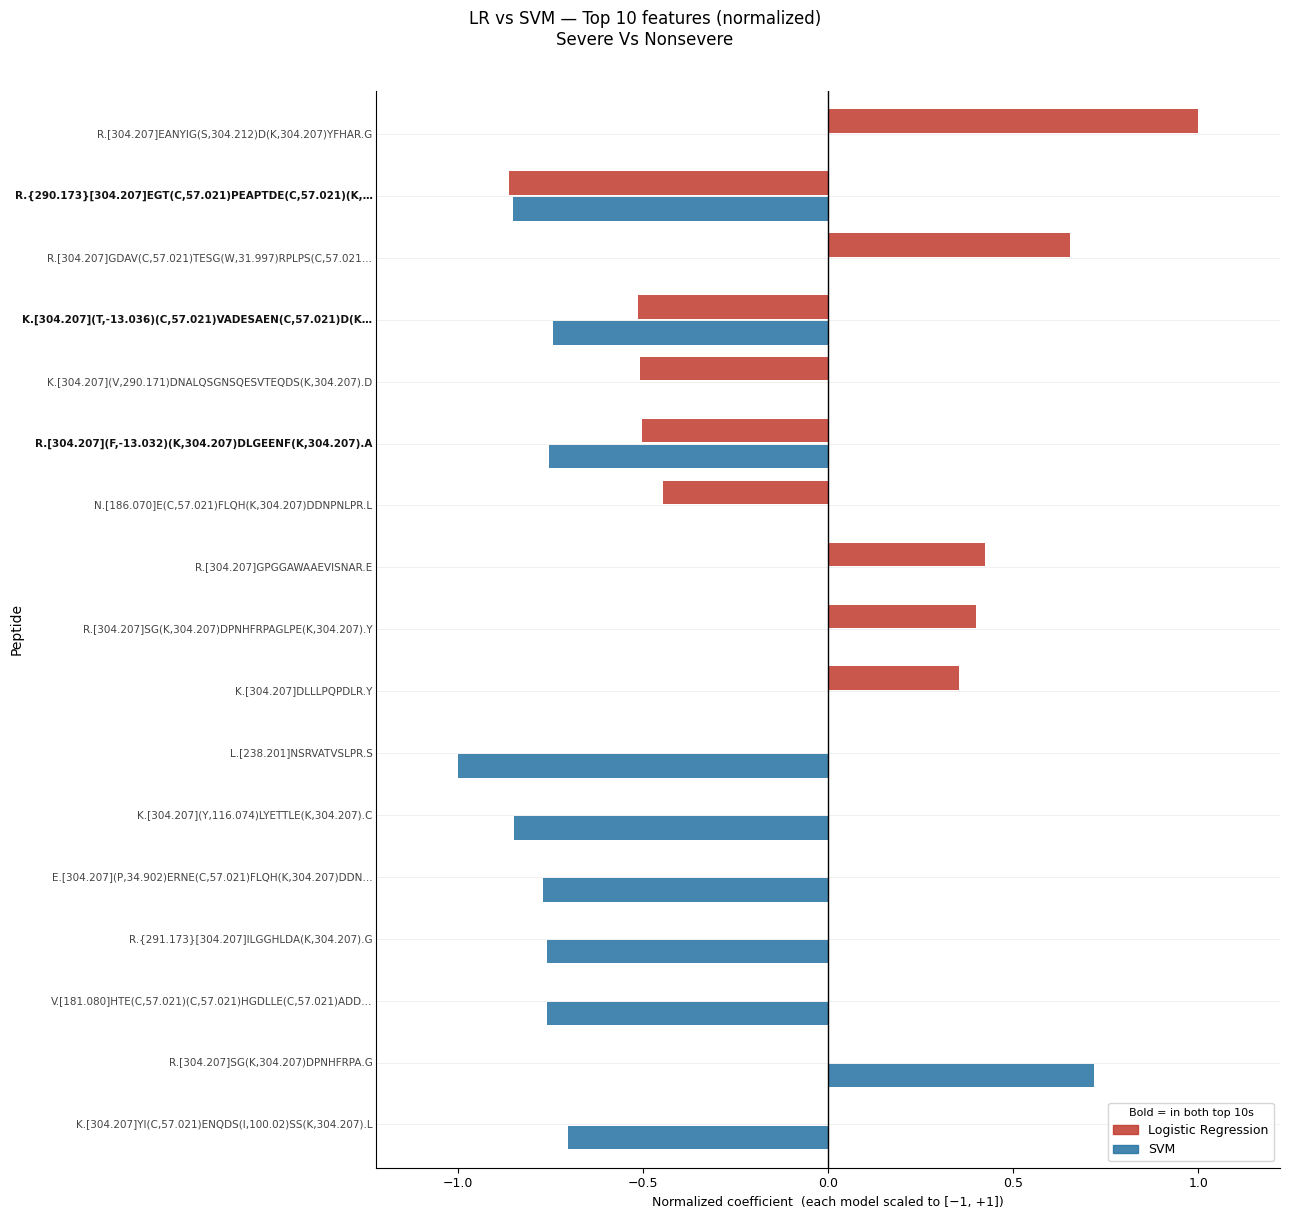

Saved: data/processed/symptomatic_non_covid_vs_covid/compare_top_feats_bar_lr_svm.png


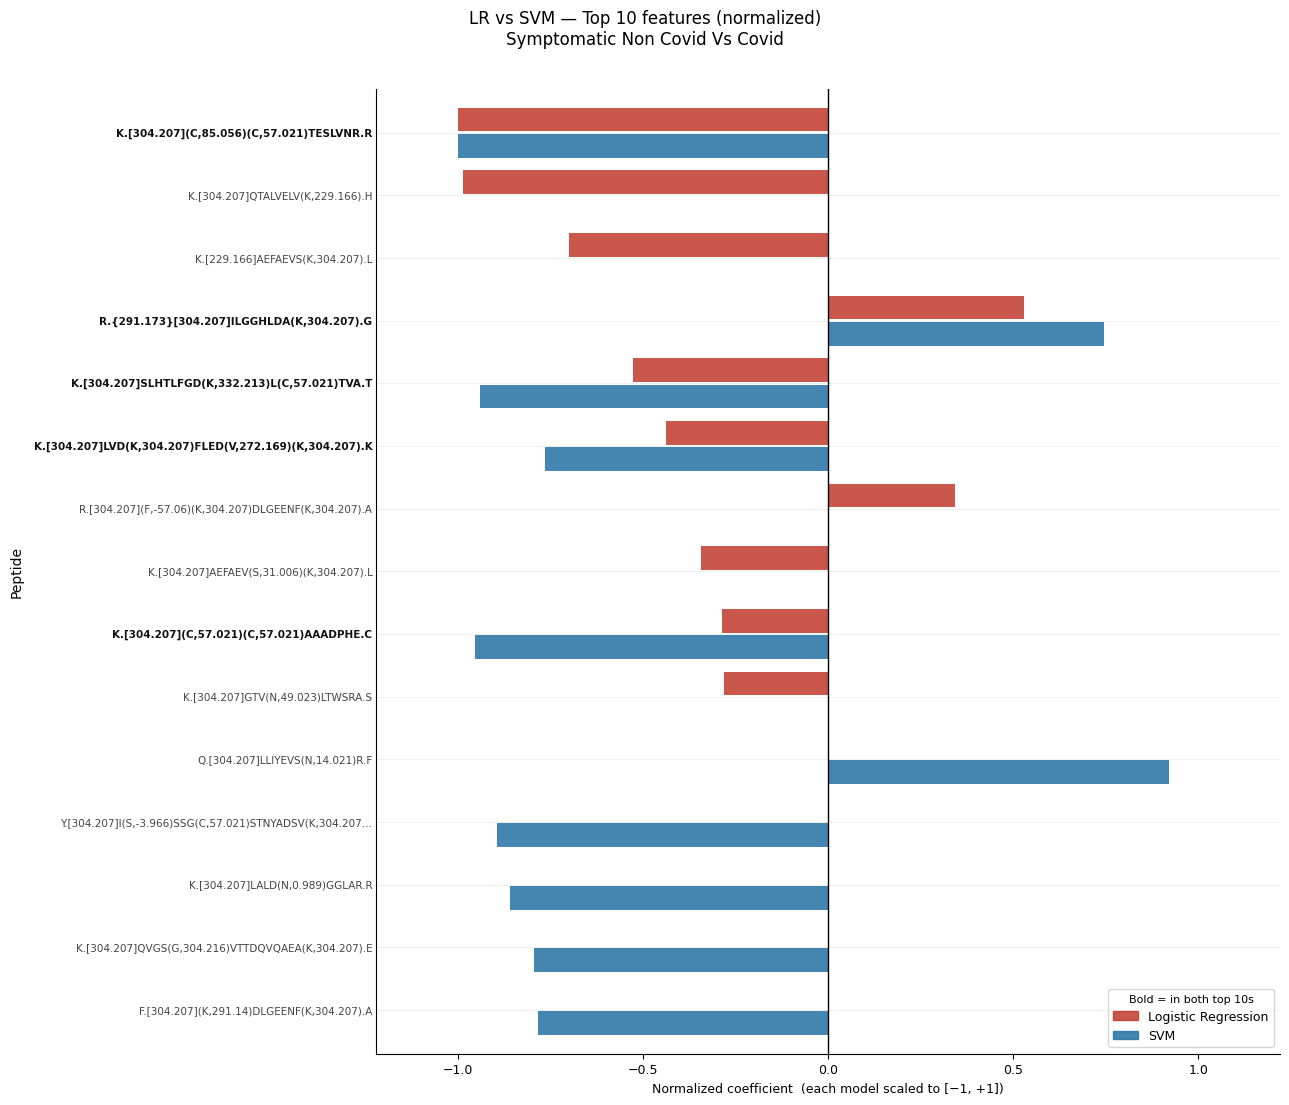

In [17]:
"""
bidirectional_lr_svm.py
────────────────────────
Overlaid bidirectional (diverging) bar chart comparing the top 10 features
from Logistic Regression (LR) and SVM on a single shared axis.

Because LR and SVM coefficients are on very different scales (LR ≈ ±0.4,
SVM ≈ ±0.01), both are normalized to [-1, +1] by dividing each model's
coefficients by its own maximum absolute coefficient before plotting.
The x-axis therefore reads as "normalized coefficient" and the bars are
directly comparable in terms of relative feature importance and direction.

Bars are slightly offset vertically (one per model) so both are visible when
they overlap.  Peptides in both top-10s are labelled in bold.

Inputs:
  logistic_regression_top_coefficients.csv
  svm_top_coefficients.csv

Output:
  bidirectional_lr_svm.png
"""

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd



for task_name in ["healthy_vs_infected", "severe_vs_nonsevere", "symptomatic_non_covid_vs_covid"]:
    LR_CSV = Path(f"data/processed/{task_name}/logistic_regression_top_coefficients.csv")
    SVM_CSV = Path(f"data/processed/{task_name}/svm_top_coefficients.csv")
    XGB_CSV = Path(f"data/processed/{task_name}/xgboost_nonlinear_feature_importance_gain.csv")
    TASK = task_name
    TOP_N   = 10

    LR_COLOR  = "#c0392b"   # red
    SVM_COLOR = "#2471a3"   # blue

    BAR_HEIGHT = 0.38       # each bar takes up this fraction of the row
    BAR_OFFSET = 0.21       # how far each bar is shifted from the row centre
    LABEL_MAX  = 54

    # ── helpers ───────────────────────────────────────────────────────────────────

    def shorten(name, n=LABEL_MAX):
        return name if len(name) <= n else name[:n - 1] + "…"

    def load_top(path, task, top_n):
        df = pd.read_csv(path)
        df = (df[df["task"] == task]
                .query("abs_coefficient > 0")
                .sort_values("abs_coefficient", ascending=False)
                .head(top_n)
                .reset_index(drop=True))
        df["rank"] = df.index + 1
        return df

    # ── load & normalize ──────────────────────────────────────────────────────────

    lr  = load_top(LR_CSV,  TASK, TOP_N)
    svm = load_top(SVM_CSV, TASK, TOP_N)

    # Normalize each model to [-1, +1]
    lr["coef_norm"]  = lr["coefficient"]  / lr["abs_coefficient"].max()
    svm["coef_norm"] = svm["coefficient"] / svm["abs_coefficient"].max()

    lr_lookup  = lr.set_index("peptide")["coef_norm"].to_dict()
    svm_lookup = svm.set_index("peptide")["coef_norm"].to_dict()

    # Union peptide list — LR top-10 first (in LR rank order), then any SVM-only
    lr_peps  = list(lr["peptide"])
    svm_peps = list(svm["peptide"])
    svm_only = [p for p in svm_peps if p not in lr_peps]
    peptides = lr_peps + svm_only     # display order (rank 1 at top → reverse for plot)
    peptides_plot = peptides[::-1]

    in_both = set(lr_peps) & set(svm_peps)

    n = len(peptides_plot)
    y = np.arange(n)

    # ── figure ────────────────────────────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(13, max(6, n * 0.56 + 2.5)))

    for yi, peptide in zip(y, peptides_plot):
        lr_val  = lr_lookup.get(peptide,  np.nan)
        svm_val = svm_lookup.get(peptide, np.nan)

        # LR bar — shifted slightly upward
        if not np.isnan(lr_val):
            ax.barh(yi + BAR_OFFSET, lr_val,
                    height=BAR_HEIGHT, color=LR_COLOR,
                    alpha=0.85, zorder=3)

        # SVM bar — shifted slightly downward
        if not np.isnan(svm_val):
            ax.barh(yi - BAR_OFFSET, svm_val,
                    height=BAR_HEIGHT, color=SVM_COLOR,
                    alpha=0.85, zorder=3)

    # Zero line
    ax.axvline(0, color="black", lw=1.0, zorder=4)

    # Light row separators
    for yi in y:
        ax.axhline(yi, color="#eeeeee", lw=0.6, zorder=0)

    # ── y-axis labels ─────────────────────────────────────────────────────────────

    ax.set_yticks(y)
    ax.set_yticklabels([])

    label_x = -1.23

    for yi, peptide in zip(y, peptides_plot):
        bold = peptide in in_both
        ax.text(
            label_x, yi,
            shorten(peptide),
            ha="right", va="center",
            fontsize=7.5,
            fontweight="bold" if bold else "normal",
            color="#111111" if bold else "#444444",
        )

    # ── axes styling ──────────────────────────────────────────────────────────────

    ax.set_xlim(-1.22, 1.22)
    ax.set_ylim(-0.7, n - 0.3)
    ax.set_xlabel(
        "Normalized coefficient  (each model scaled to [−1, +1])",
        fontsize=9,
    )
    ax.set_ylabel("Peptide", fontsize=10, labelpad=250)   # labelpad pushes it left of the long labels
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=9)

    # ── legend ────────────────────────────────────────────────────────────────────

    legend_handles = [
        mpatches.Patch(color=LR_COLOR,  alpha=0.85, label="Logistic Regression"),
        mpatches.Patch(color=SVM_COLOR, alpha=0.85, label="SVM"),
    ]
    ax.legend(
        handles=legend_handles,
        fontsize=9,
        frameon=True,
        loc="lower right",
        title=f"Bold = in both top {TOP_N}s",
        title_fontsize=8,
    )

    fig.suptitle(
        f"LR vs SVM — Top {TOP_N} features (normalized)\n"
        f"{TASK.replace('_', ' ').title()}",
        fontsize=12, fontweight="medium", y=1.01,
    )

    plt.tight_layout()

    out = Path(f"data/processed/{task_name}/compare_top_feats_bar_lr_svm.png")
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white", edgecolor="white")
    print(f"Saved: {out}")
    plt.show()
    plt.close(fig)